In [7]:
import numpy as np
import pandas as pd
from scipy.stats import binomtest
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- ServC ----------
def servc_scores(tau_ad, tau_da, w_d, phi_prox, kappa=0.0):
    tau_ad = np.asarray(tau_ad, dtype=float)  # |A| x |D|
    tau_da = np.asarray(tau_da, dtype=float)  # |A| x |D|
    w_d = np.asarray(w_d, dtype=float).reshape(1, -1)   # 1 x |D|
    phi_prox = np.asarray(phi_prox, dtype=float).reshape(-1, 1)  # |A| x 1
    eps = 1e-9
    servc_AD = (w_d / (tau_ad + kappa * phi_prox + eps)).sum(axis=1)
    servc_DA = (w_d / (tau_da + kappa * phi_prox + eps)).sum(axis=1)
    return dict(servc_AD=servc_AD, servc_DA=servc_DA)

def baseline_closeness_B3(tau_matrix, w_d):
    tau = np.asarray(tau_matrix, dtype=float)
    w = np.asarray(w_d, dtype=float).reshape(1, -1)
    eps = 1e-9
    return (w / (tau + eps)).sum(axis=1)  # NOTA: equivalente a ServC con kappa=0

# ---------- Selettori Top / Median ----------
def top_k_indices(scores, q):
    A = scores.shape[0]
    k = max(1, int(np.floor(q * A)))
    return np.argsort(scores)[::-1][:k]

def median_k_indices(scores, q):
    """
    Prende il blocco 'mediano' di dimensione k all'interno dell'ordinamento decrescente dei punteggi.
    Se A=10 e k=4 → prende gli indici 3,4,5,6 del ranking (centrati).
    """
    A = scores.shape[0]
    k = max(1, int(np.floor(q * A)))
    order = np.argsort(scores)[::-1]
    start = max(0, (A - k) // 2)
    end = start + k
    return order[start:end]

# ---------- Copertura & curve ----------
def weighted_coverage_share(tau_matrix, w_d, selected_A_indices, tau_star):
    tau = np.asarray(tau_matrix, dtype=float)
    w = np.asarray(w_d, dtype=float)
    if len(selected_A_indices) == 0:
        return 0.0
    mins = tau[selected_A_indices, :].min(axis=0)
    covered = (mins <= float(tau_star))
    return float((w[covered]).sum() / (w.sum() + 1e-12))

def coverage_curve_from_selector(scores, selector_fn, tau_matrix, w_d, Qgrid, tau_star):
    cov = []
    for q in Qgrid:
        idx = selector_fn(scores, q)
        cov.append(weighted_coverage_share(tau_matrix, w_d, idx, tau_star))
    return np.array(cov)

def auc_trapz(y, x): return float(np.trapz(y, x))

# ---------- Bootstrap & dominance ----------
def bootstrap_curves_selectors(scores, selector_main, selector_base,
                               tau_matrix, w_d, Qgrid, tau_star, B=1000, rng=None):
    rng = np.random.default_rng(rng)
    A, D = tau_matrix.shape
    Q = len(Qgrid)

    curves_main = np.zeros((B, Q))
    curves_base = np.zeros((B, Q))
    for b in range(B):
        sample_idx = rng.integers(0, D, size=D)  # resample demand
        w_b = w_d[sample_idx]
        tau_b = tau_matrix[:, sample_idx]
        curves_main[b] = coverage_curve_from_selector(scores, selector_main, tau_b, w_b, Qgrid, tau_star)
        curves_base[b] = coverage_curve_from_selector(scores, selector_base, tau_b, w_b, Qgrid, tau_star)
    return dict(main=curves_main, base=curves_base, diff=curves_main - curves_base)

def dominance_pvalues(diff_curves):
    B, Q = diff_curves.shape
    pvals = np.zeros(Q)
    for j in range(Q):
        wins = int(np.sum(diff_curves[:, j] > 0))
        pvals[j] = binomtest(wins, B, p=0.5, alternative='greater').pvalue
    return pvals

def ci_band(curves, alpha=0.05):
    lower = np.percentile(curves, 100*(alpha/2), axis=0)
    upper = np.percentile(curves, 100*(1-alpha/2), axis=0)
    mean = curves.mean(axis=0)
    return mean, lower, upper

# ---------- Runner città ----------
def run_city_h2(city_name, tau_ad, tau_da, w_d, phi_prox,
                kappa=0.0,  # se >0 attivi curb usability nella ServC
                Qgrid=None, tau_list=(300, 600), B=1000,
                out_dir="outputs", compare_to="median"):  # "median" oppure "B3"
    Path(out_dir).mkdir(parents=True, exist_ok=True)
    if Qgrid is None:
        Qgrid = np.linspace(0.05, 1.0, 20)

    sc = servc_scores(tau_ad, tau_da, w_d, phi_prox, kappa=kappa)
    servc_AD, servc_DA = sc['servc_AD'], sc['servc_DA']

    # Baseline selector
    if compare_to == "median":
        base_selector = median_k_indices
        base_label_fmt = "Median block"
    elif compare_to == "B3":
        # baseline per ranking: B3 con kappa=0
        base_AD = baseline_closeness_B3(tau_ad, w_d)
        base_DA = baseline_closeness_B3(tau_da, w_d)
        # ma per la curva vogliamo usare lo stesso q → usiamo comunque i blocchi top vs top,
        # cambiando i punteggi che inducono l'ordinamento:
        def make_top_selector_with_scores(scores_for_baseline):
            return lambda scores_unused, q: top_k_indices(scores_for_baseline, q)
        base_sel_AD = make_top_selector_with_scores(base_AD)
        base_sel_DA = make_top_selector_with_scores(base_DA)
        base_label_fmt = "Baseline B3"
    else:
        raise ValueError("compare_to must be 'median' or 'B3'")

    rows = []
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), dpi=150)

    specs = [
        ("DA", servc_DA, tau_da, base_selector if compare_to=="median" else base_sel_DA),
        ("AD", servc_AD, tau_ad, base_selector if compare_to=="median" else base_sel_AD),
    ]

    for ax, orient, scores_main, tau_matrix, base_sel in [
        (axes[0], "DA", servc_DA, tau_da, specs[0][3]),
        (axes[1], "AD", servc_AD, tau_ad, specs[1][3]),
    ]:
        for tau_star in tau_list:
            boot = bootstrap_curves_selectors(
                scores_main,
                selector_main=top_k_indices,
                selector_base=(base_sel if compare_to=="median" else base_sel),
                tau_matrix=tau_matrix, w_d=w_d,
                Qgrid=Qgrid, tau_star=tau_star, B=B, rng=42
            )
            mean_m, lo_m, hi_m = ci_band(boot['main'])
            mean_b, lo_b, hi_b = ci_band(boot['base'])

            ax.plot(Qgrid, mean_m, label=f"Top-q ServC ({orient}), τ*={int(tau_star/60)}′")
            ax.fill_between(Qgrid, lo_m, hi_m, alpha=0.15)
            ax.plot(Qgrid, mean_b, linestyle='--', label=f"{base_label_fmt} ({orient}), τ*={int(tau_star/60)}′")
            ax.fill_between(Qgrid, lo_b, hi_b, alpha=0.10)

            auc_servc = auc_trapz(mean_m, Qgrid)
            auc_base  = auc_trapz(mean_b, Qgrid)
            delta_auc = auc_servc - auc_base
            pvals = dominance_pvalues(boot['diff'])

            rows.append({
                "City": city_name,
                "Orientation": orient,
                "tau_star_sec": tau_star,
                "AUC_ServC": auc_servc,
                "AUC_Baseline": auc_base,
                "Delta_AUC": delta_auc,
                "Max_pval_over_q": float(np.max(pvals)),
                "Frac_q_dominate_at_5pct": float(np.mean(pvals < 0.05)),
                "CompareTo": compare_to,
                "kappa": kappa,
            })

        ax.set_xlabel("Access quantile q")
        ax.set_ylabel("Weighted coverage")
        ax.set_title(f"{city_name} – {orient}")
        ax.set_xlim(Qgrid.min(), Qgrid.max()); ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.25); ax.legend(loc="lower right")

    fig.tight_layout()
    tag = f"{compare_to}_k{kappa}".replace(".","p")
    fig_path = Path(out_dir) / f"fig-servc-coverage_{tag}_{city_name.replace(' ','_')}.png"
    fig.savefig(fig_path, bbox_inches="tight")

    df = pd.DataFrame(rows)
    csv_path = Path(out_dir) / f"h2_auc_{tag}_{city_name.replace(' ','_')}.csv"
    df.to_csv(csv_path, index=False)

    # LaTeX snippet
    def _fmt(x): 
        return f"{x:.3f}" if isinstance(x, (int, float, np.floating)) else str(x)
    lines = [
        "\\begin{tabular}{lrrrrr}",
        "\\toprule",
        "Orientation & $\\tau^*$ (s) & AUC (Top-q) & AUC (Baseline) & $\\Delta$AUC & Dominance $p_{\\max}$ \\\\",
        "\\midrule",
    ]
    for _, r in df.iterrows():
        lines.append(
            f"{r['Orientation']} & {int(r['tau_star_sec'])} & {_fmt(r['AUC_ServC'])} & {_fmt(r['AUC_Baseline'])} & {_fmt(r['Delta_AUC'])} & {_fmt(r['Max_pval_over_q'])} \\\\"
        )
    lines += ["\\bottomrule", "\\end{tabular}"]
    tex_path = Path(out_dir) / f"h2_auc_{tag}_{city_name.replace(' ','_')}.tex"
    with open(tex_path, "w") as f:
        f.write("\n".join(lines))

    print(f"Saved: {fig_path}")
    print(f"Saved: {csv_path}")
    print(f"Saved: {tex_path}")
    return df, fig_path, csv_path, tex_path


=== Amsterdam, Netherlands ===  |A|=30  |D|=409
  -> Vehicle: van  (weight=c_eff_van)
Saved: outputs_h2/amsterdam-netherlands/van/fig-servc-coverage_median_k0p0_Amsterdam,_Netherlands_[van].png
Saved: outputs_h2/amsterdam-netherlands/van/h2_auc_median_k0p0_Amsterdam,_Netherlands_[van].csv
Saved: outputs_h2/amsterdam-netherlands/van/h2_auc_median_k0p0_Amsterdam,_Netherlands_[van].tex
Saved: outputs_h2/amsterdam-netherlands/van/fig-servc-coverage_B3_k1p0_Amsterdam,_Netherlands_[van].png
Saved: outputs_h2/amsterdam-netherlands/van/h2_auc_B3_k1p0_Amsterdam,_Netherlands_[van].csv
Saved: outputs_h2/amsterdam-netherlands/van/h2_auc_B3_k1p0_Amsterdam,_Netherlands_[van].tex
  -> Vehicle: cargo_bike  (weight=c_eff_cargo_bike)
Saved: outputs_h2/amsterdam-netherlands/cargo_bike/fig-servc-coverage_median_k0p0_Amsterdam,_Netherlands_[cargo_bike].png
Saved: outputs_h2/amsterdam-netherlands/cargo_bike/h2_auc_median_k0p0_Amsterdam,_Netherlands_[cargo_bike].csv
Saved: outputs_h2/amsterdam-netherlands/c

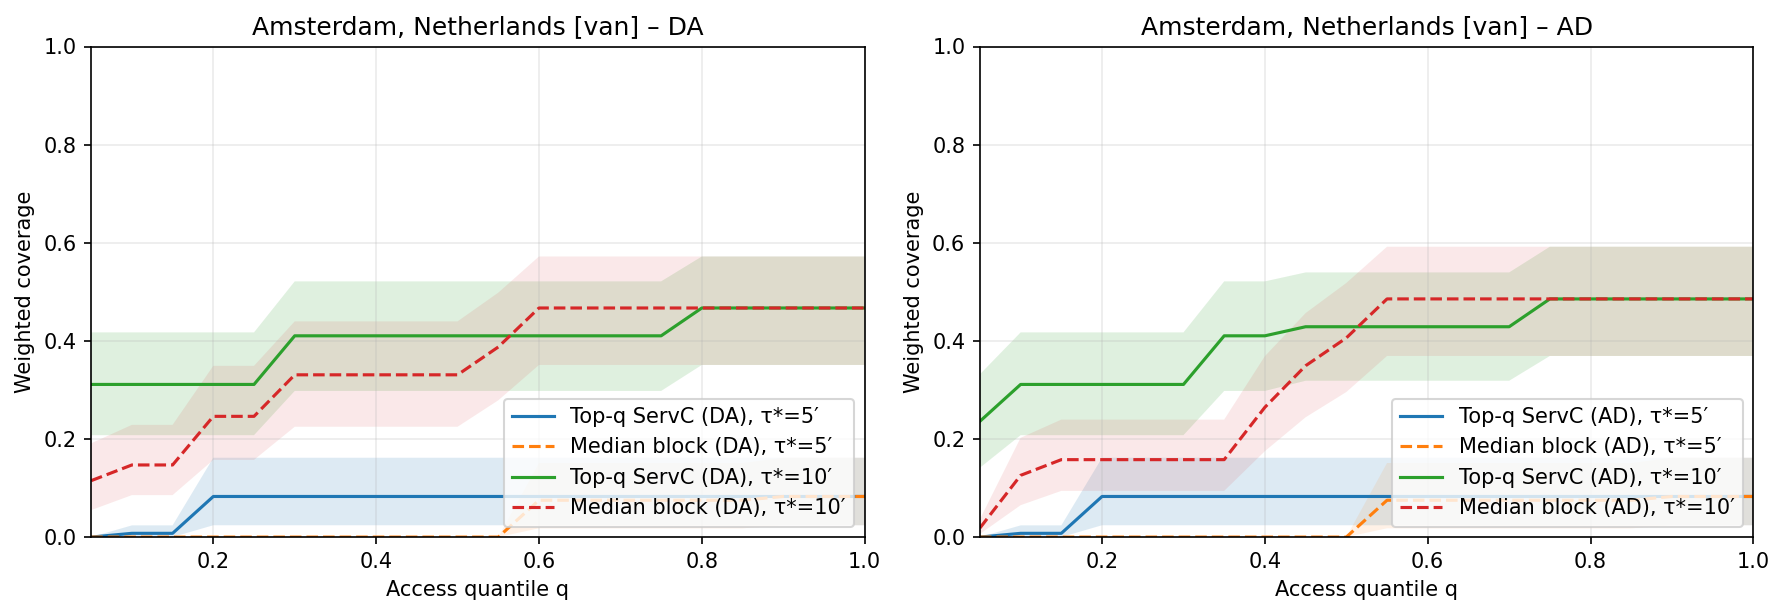

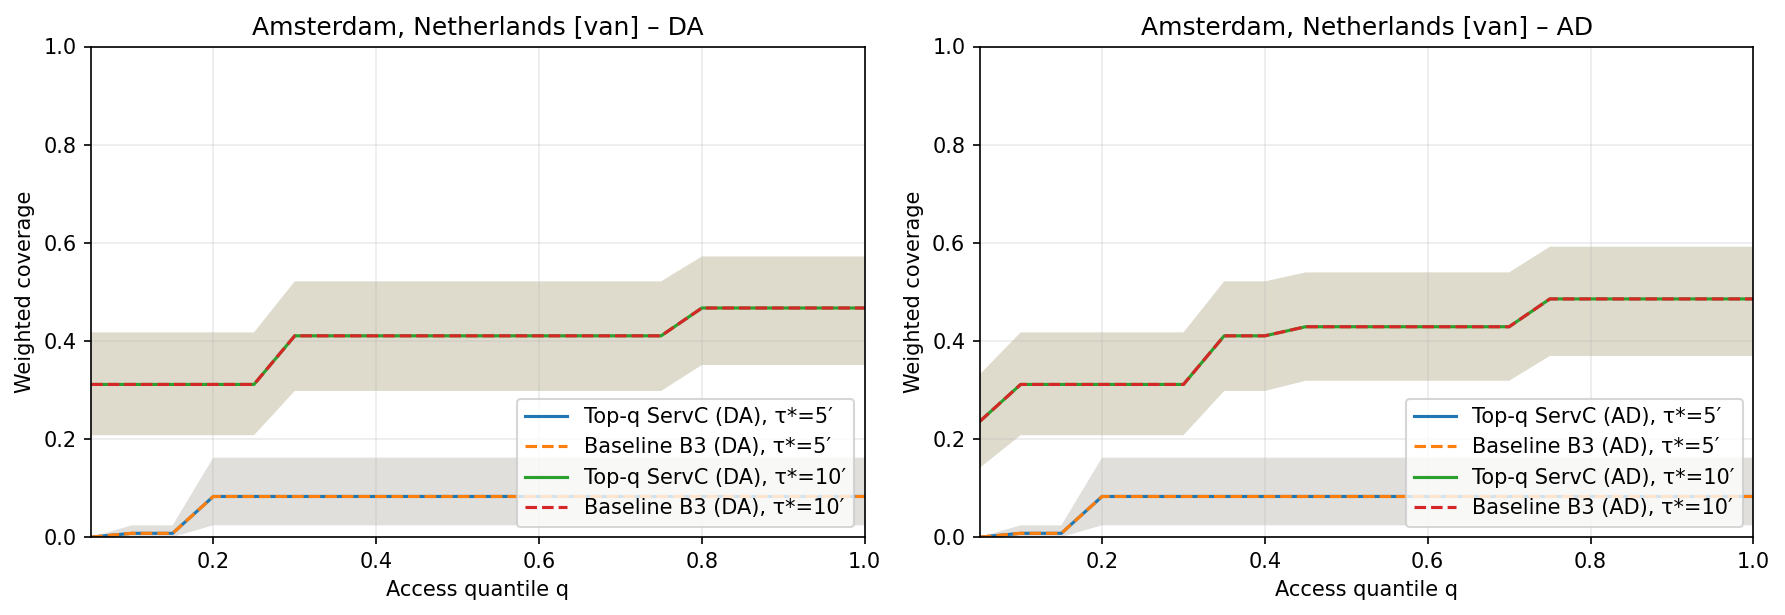

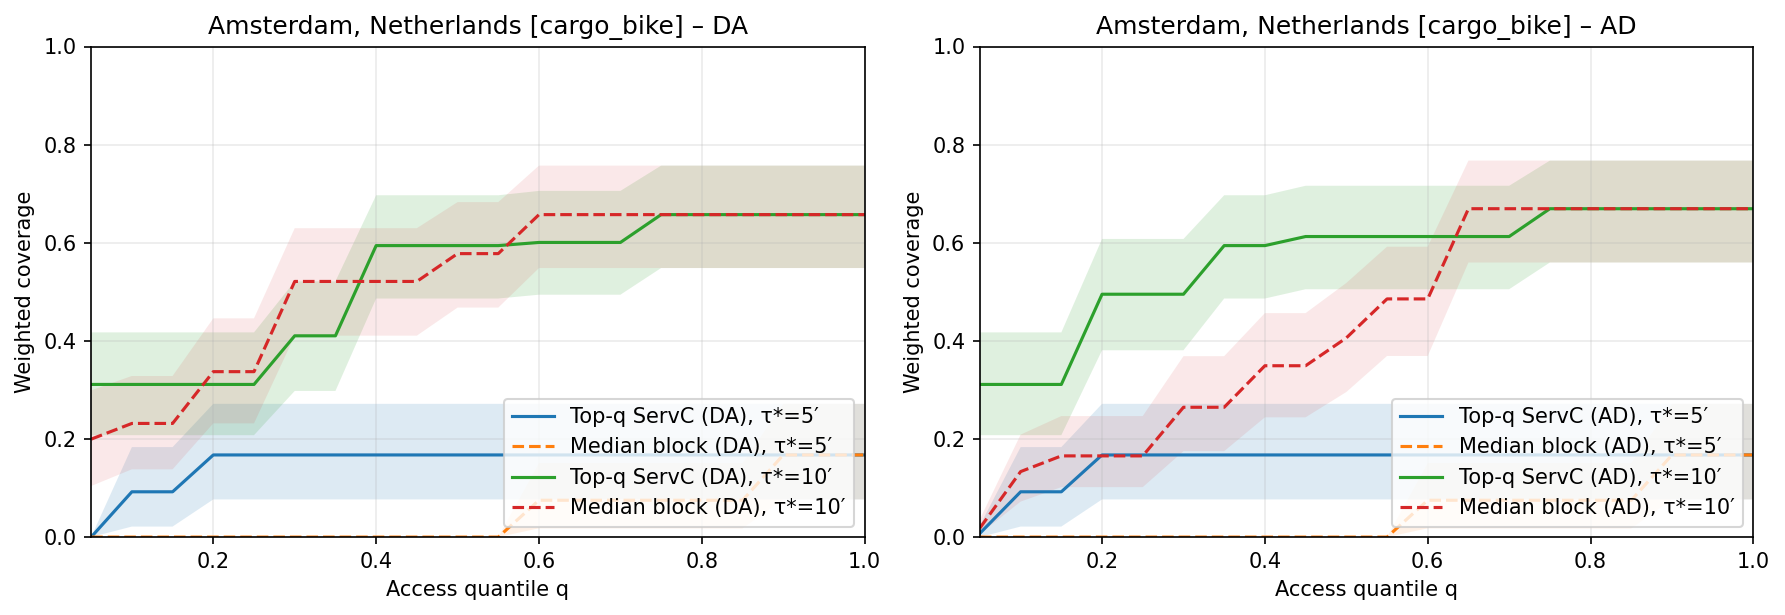

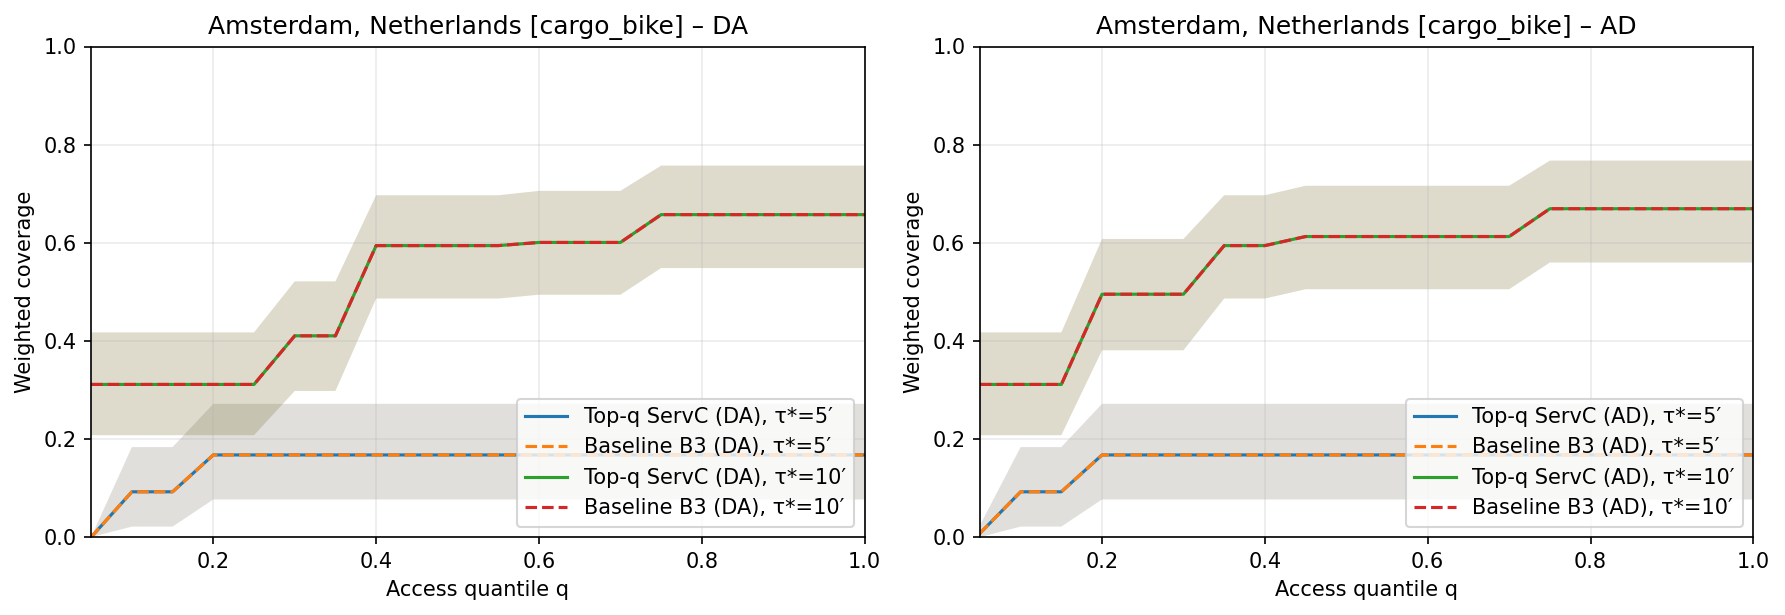

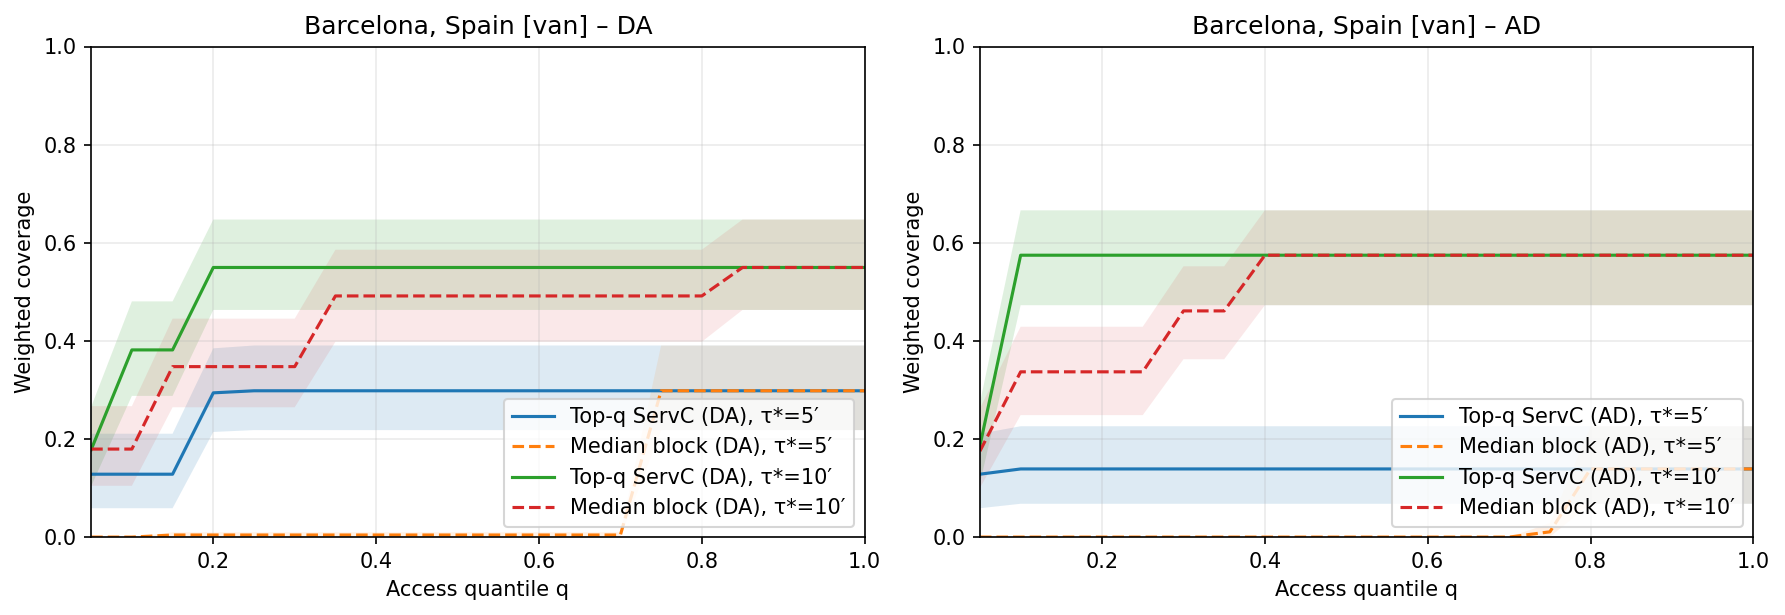

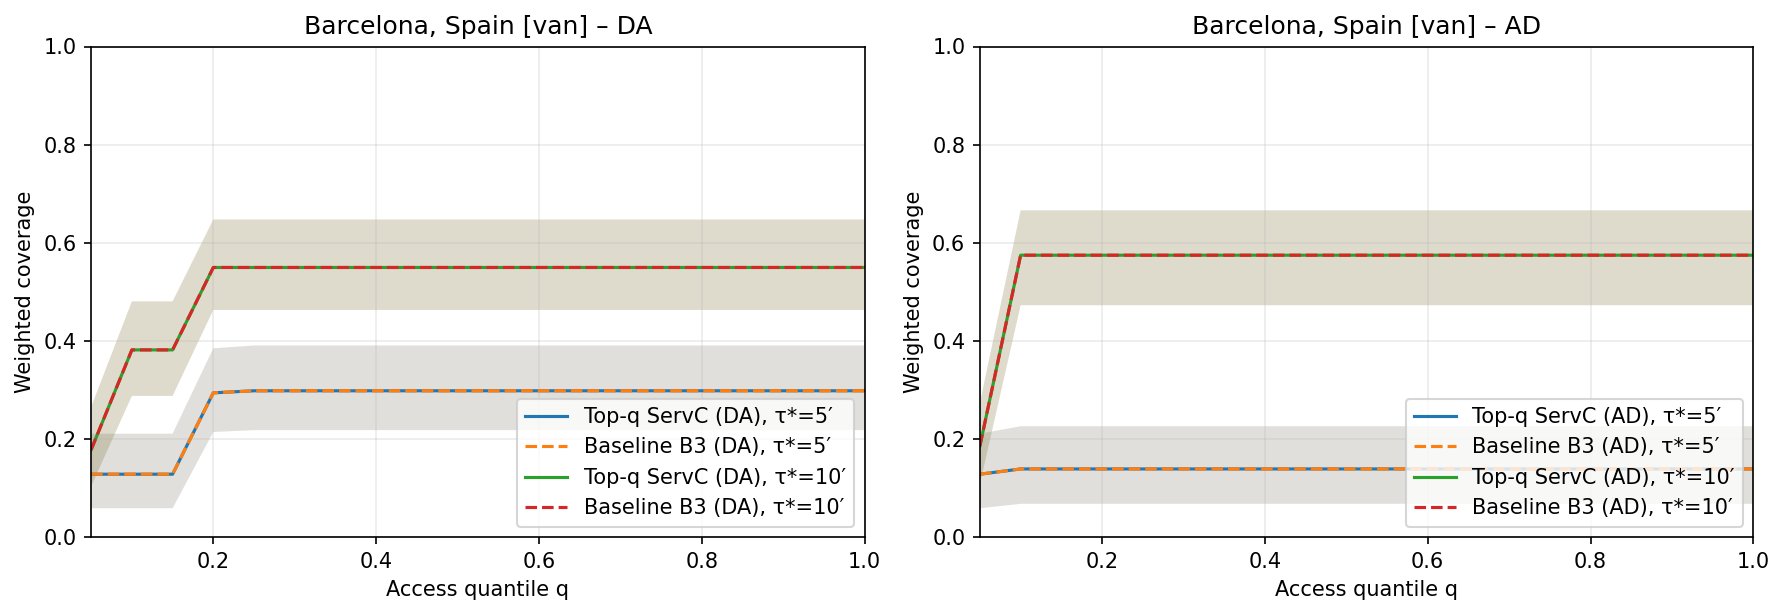

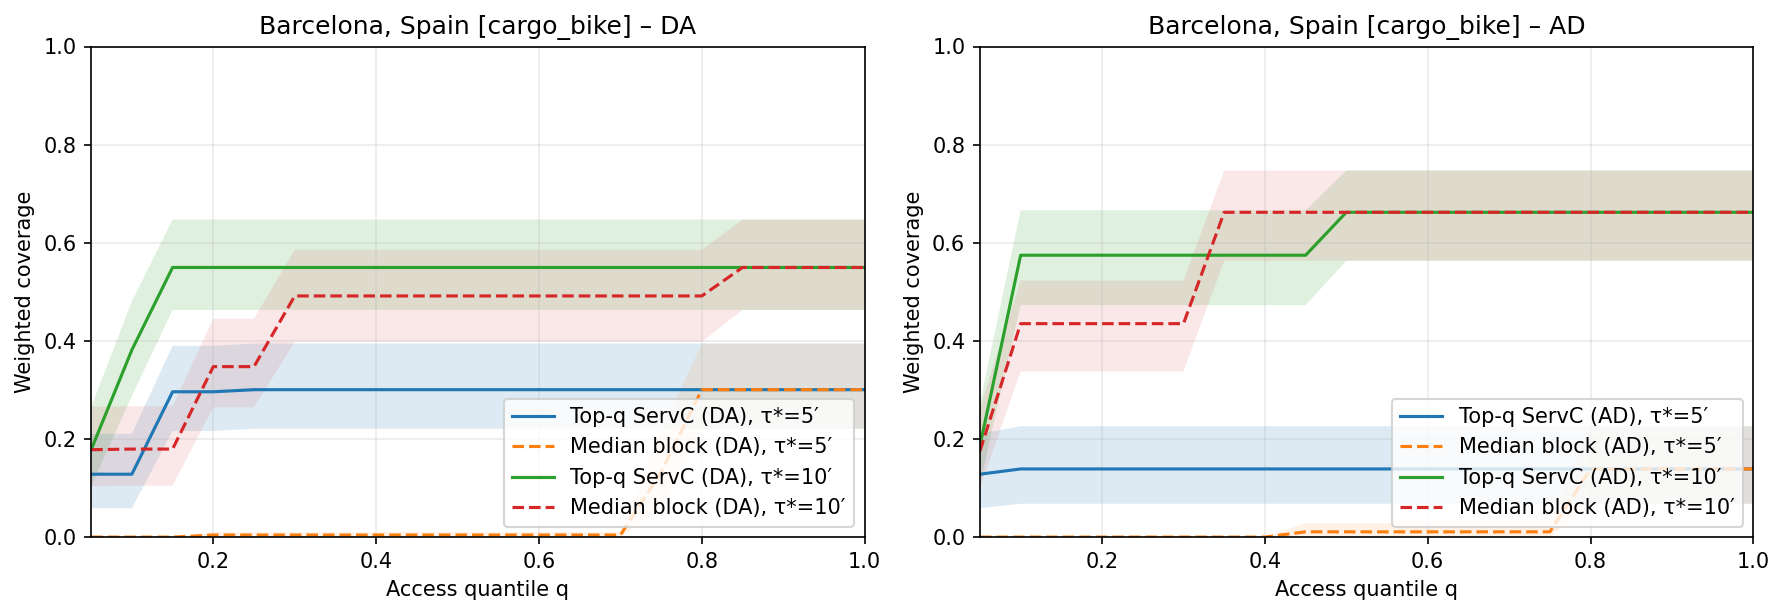

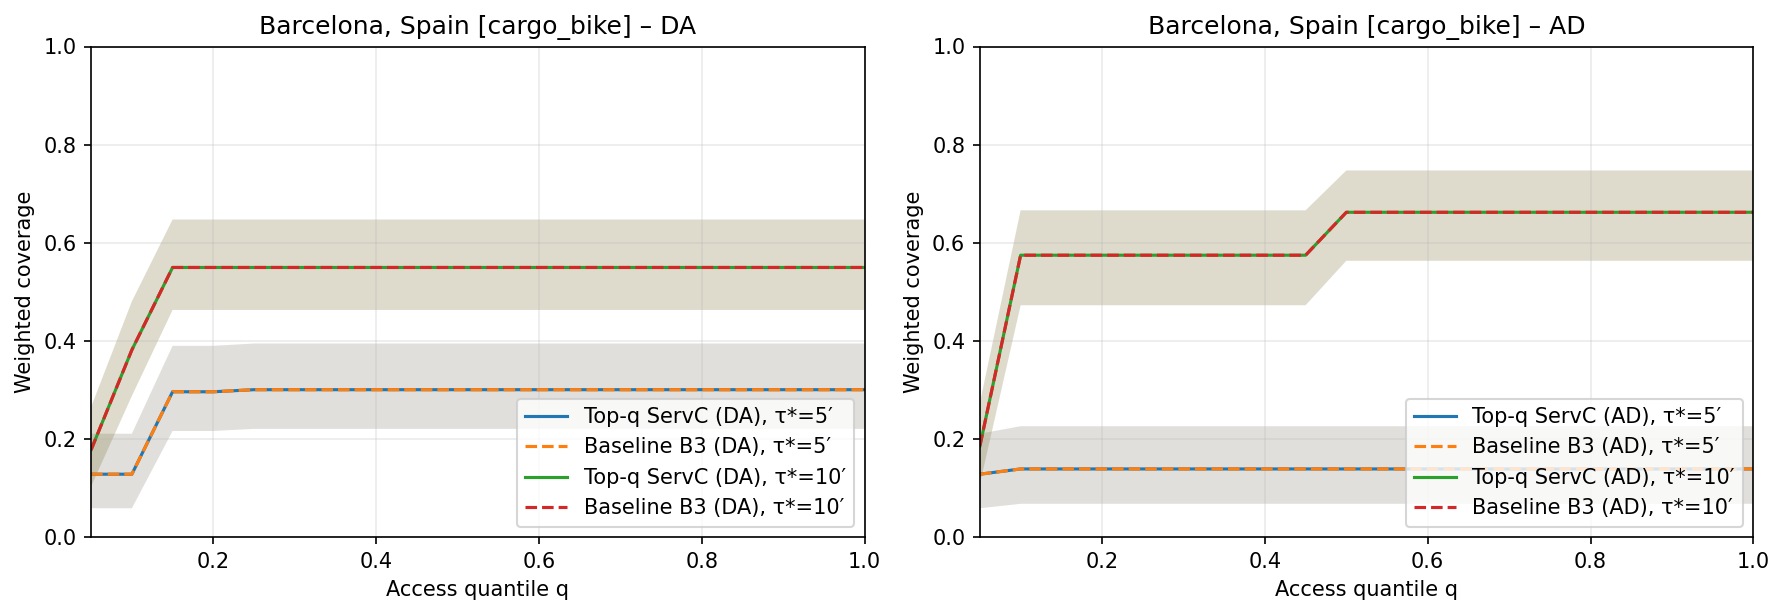

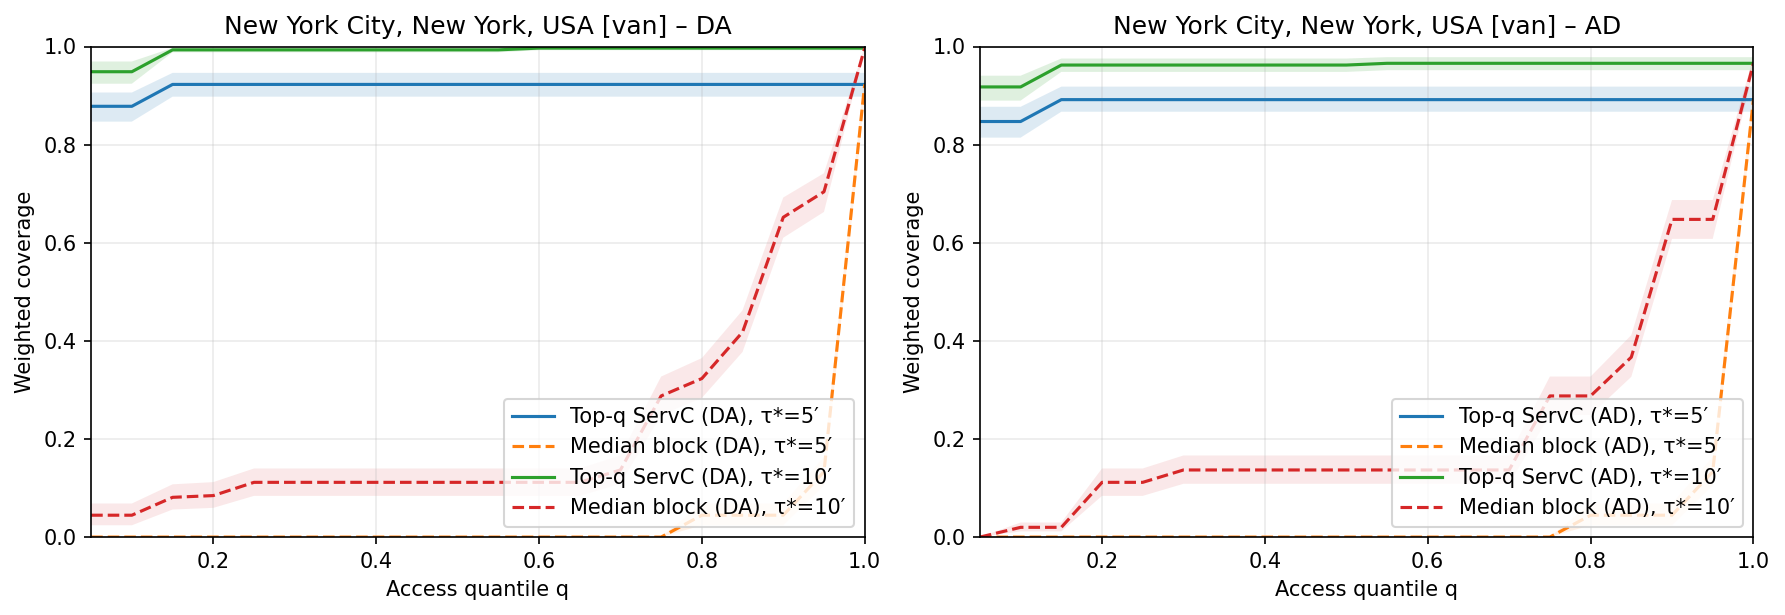

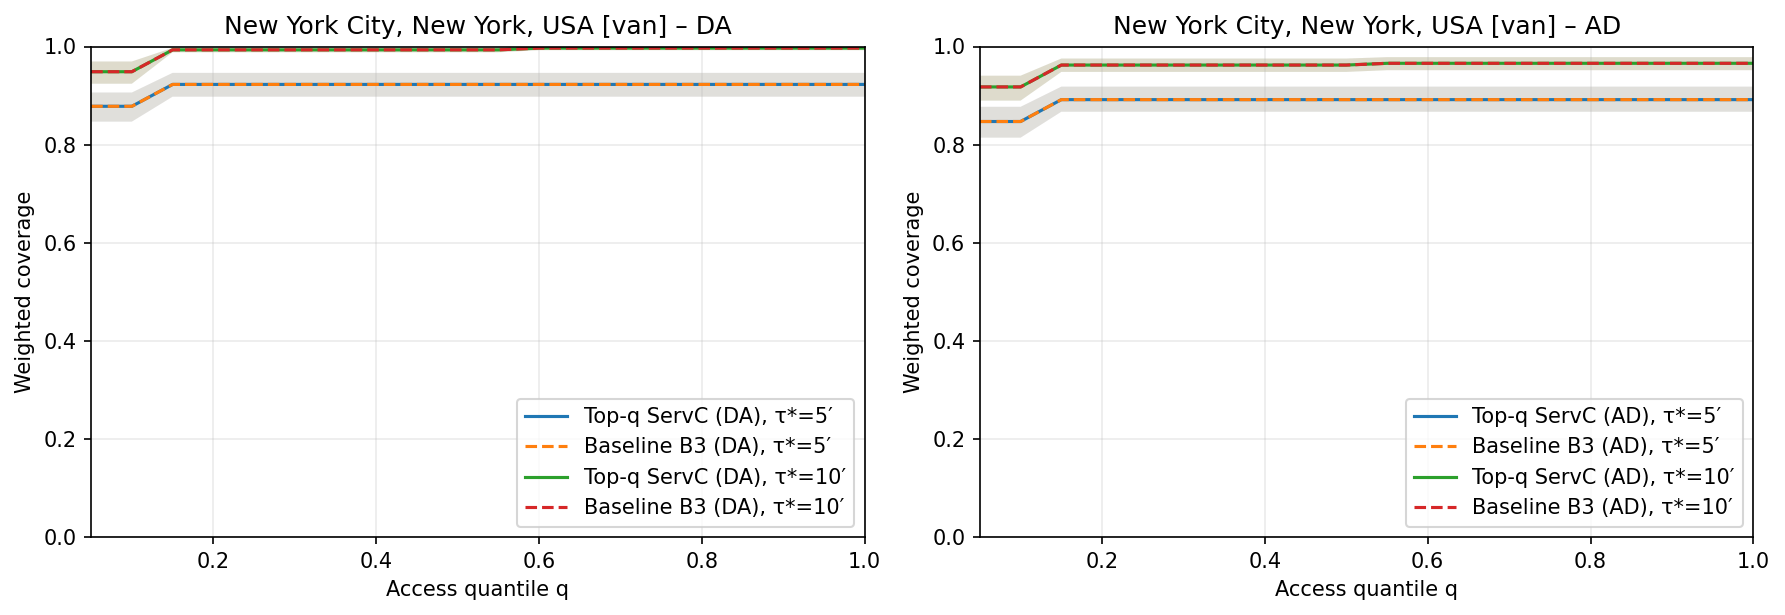

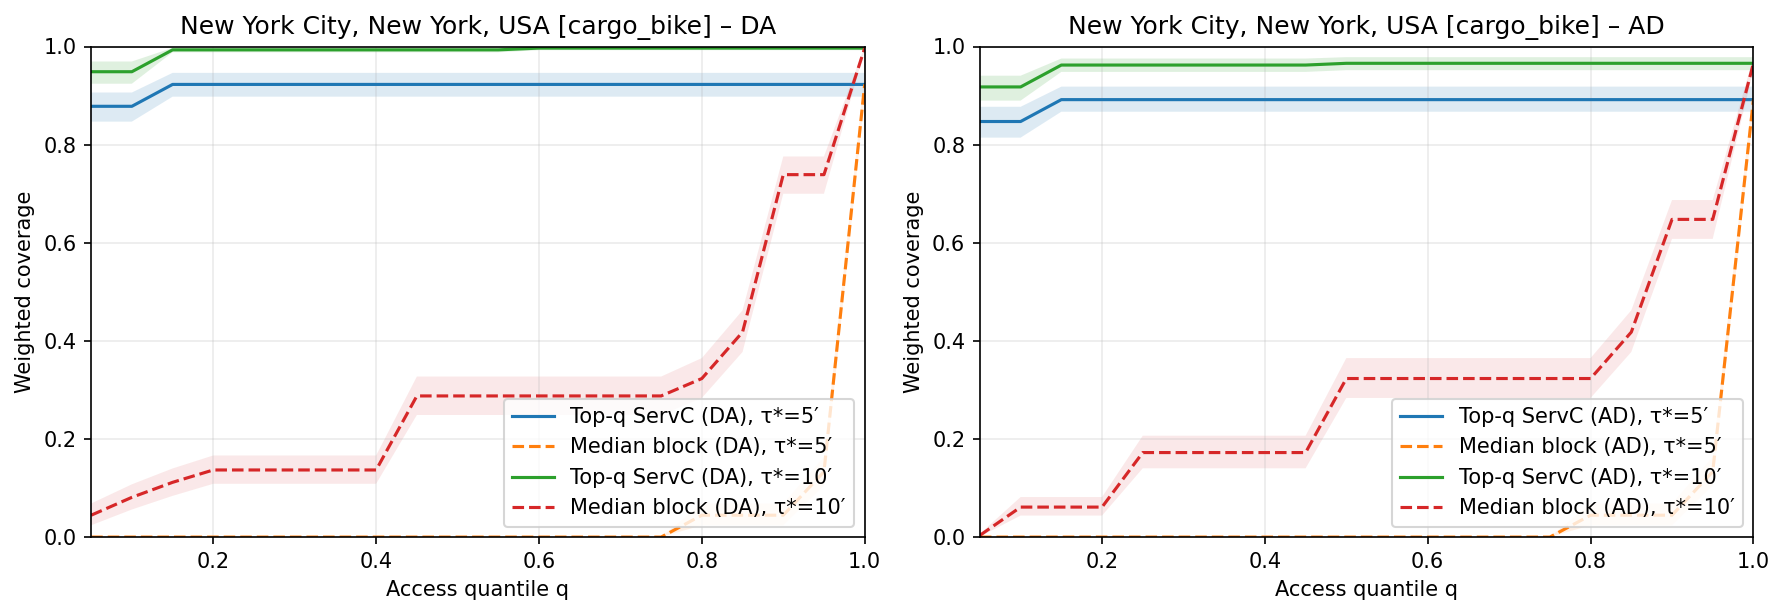

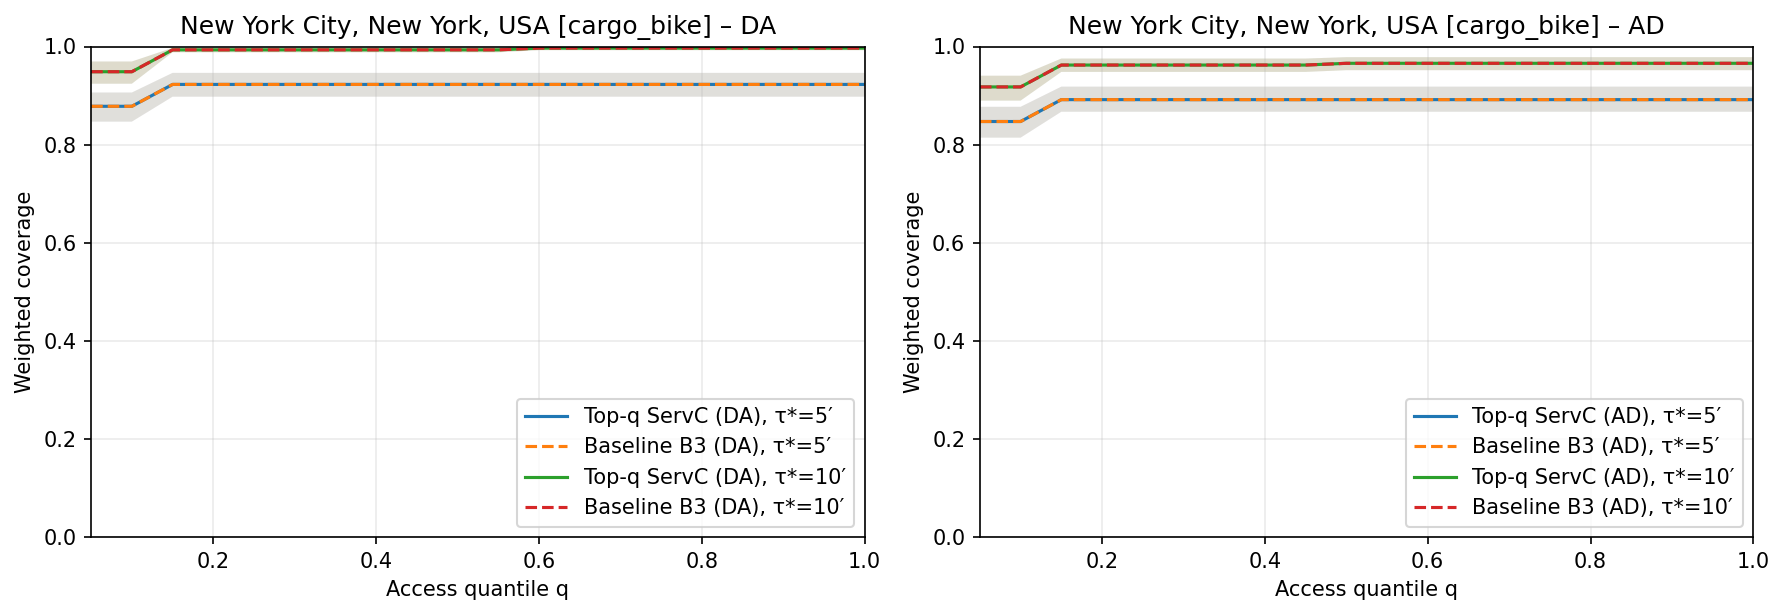

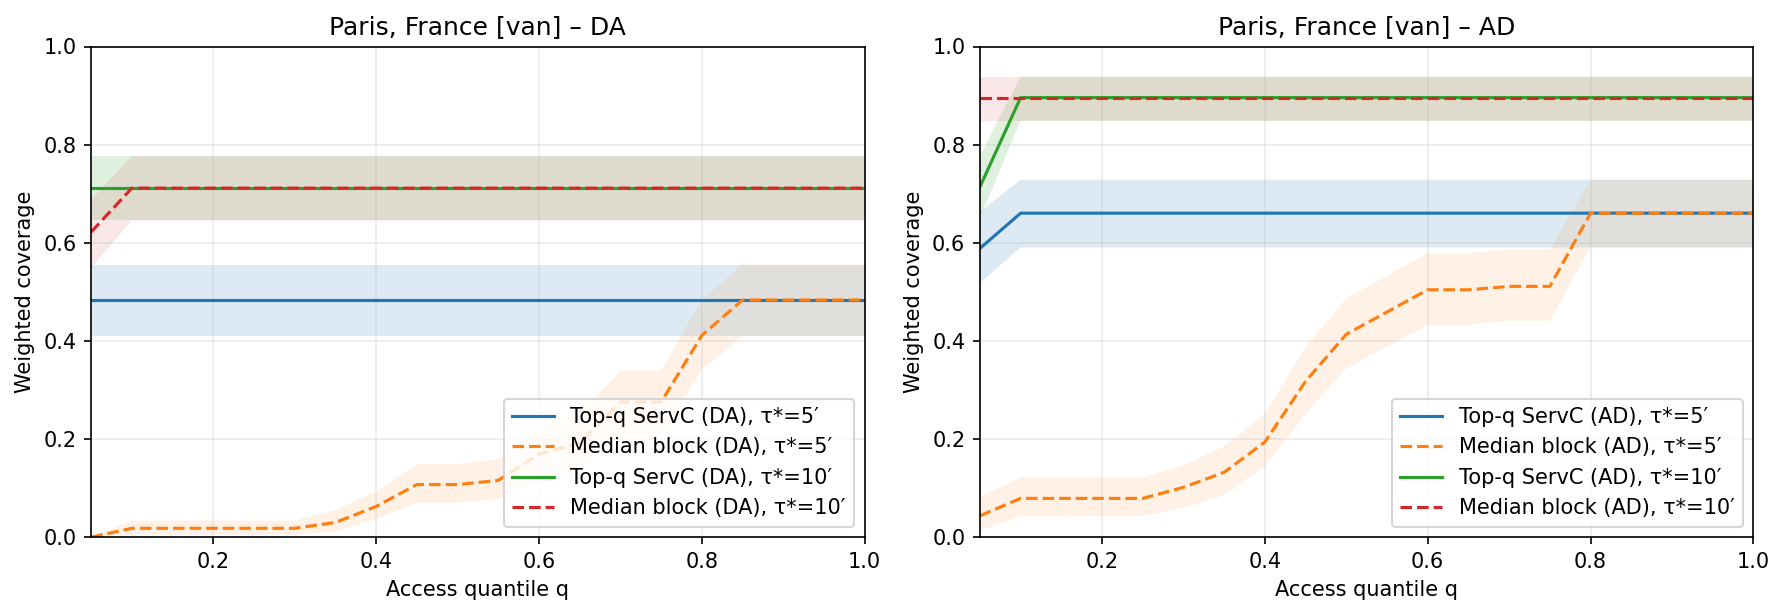

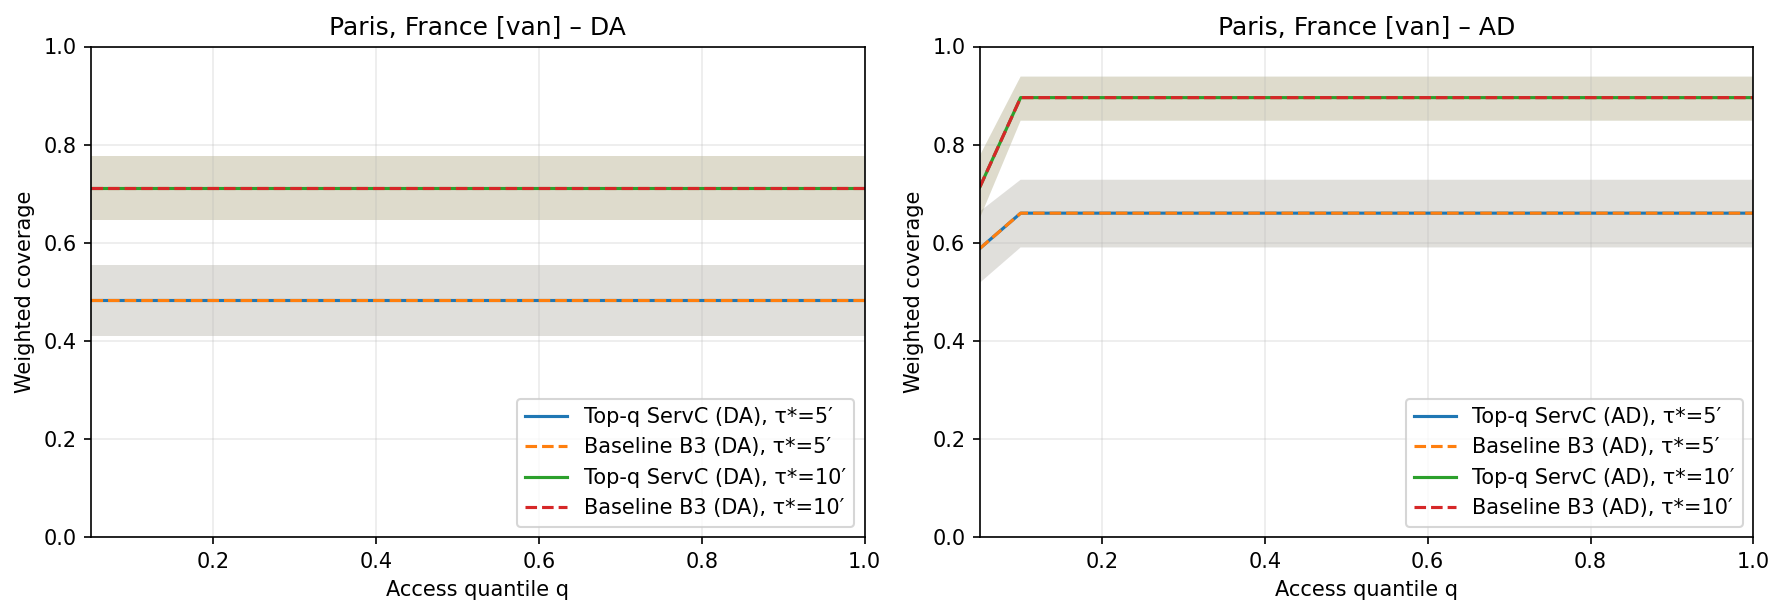

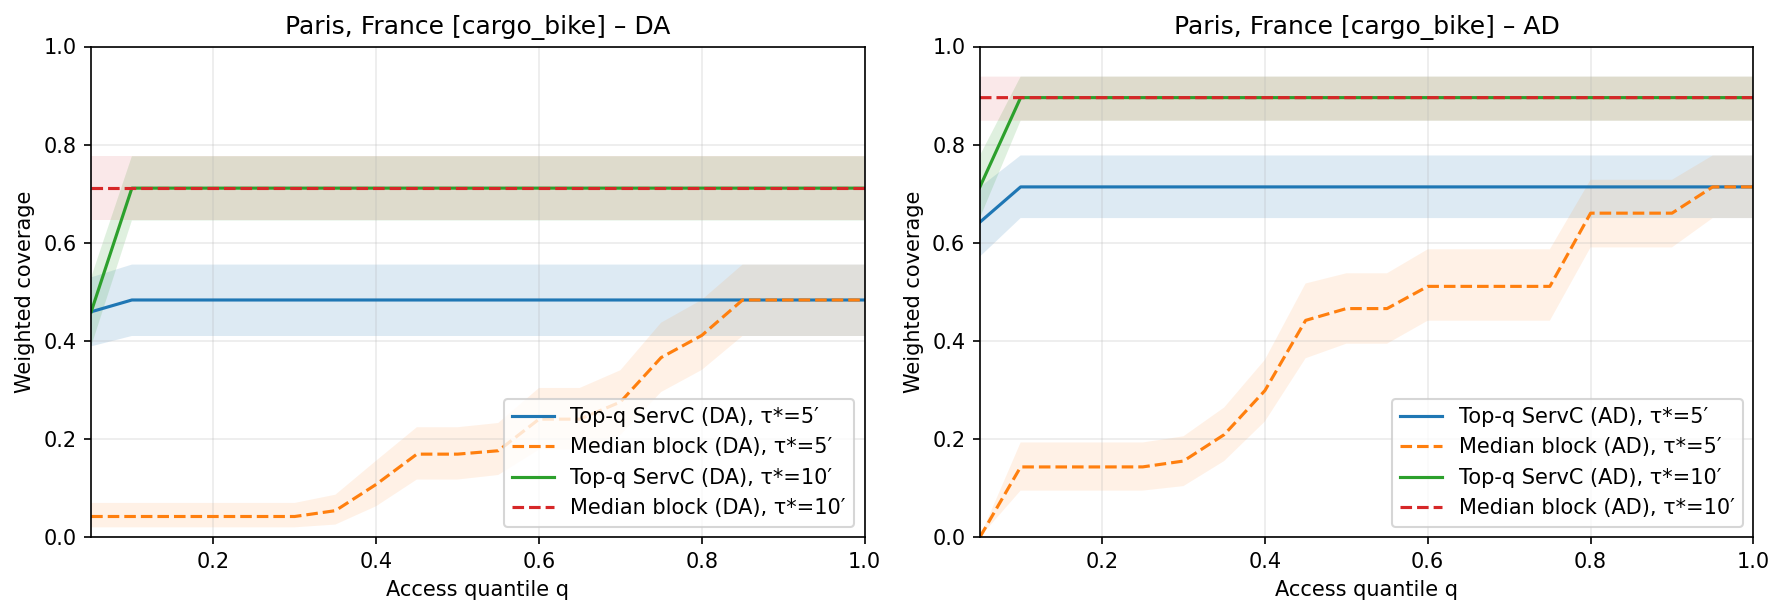

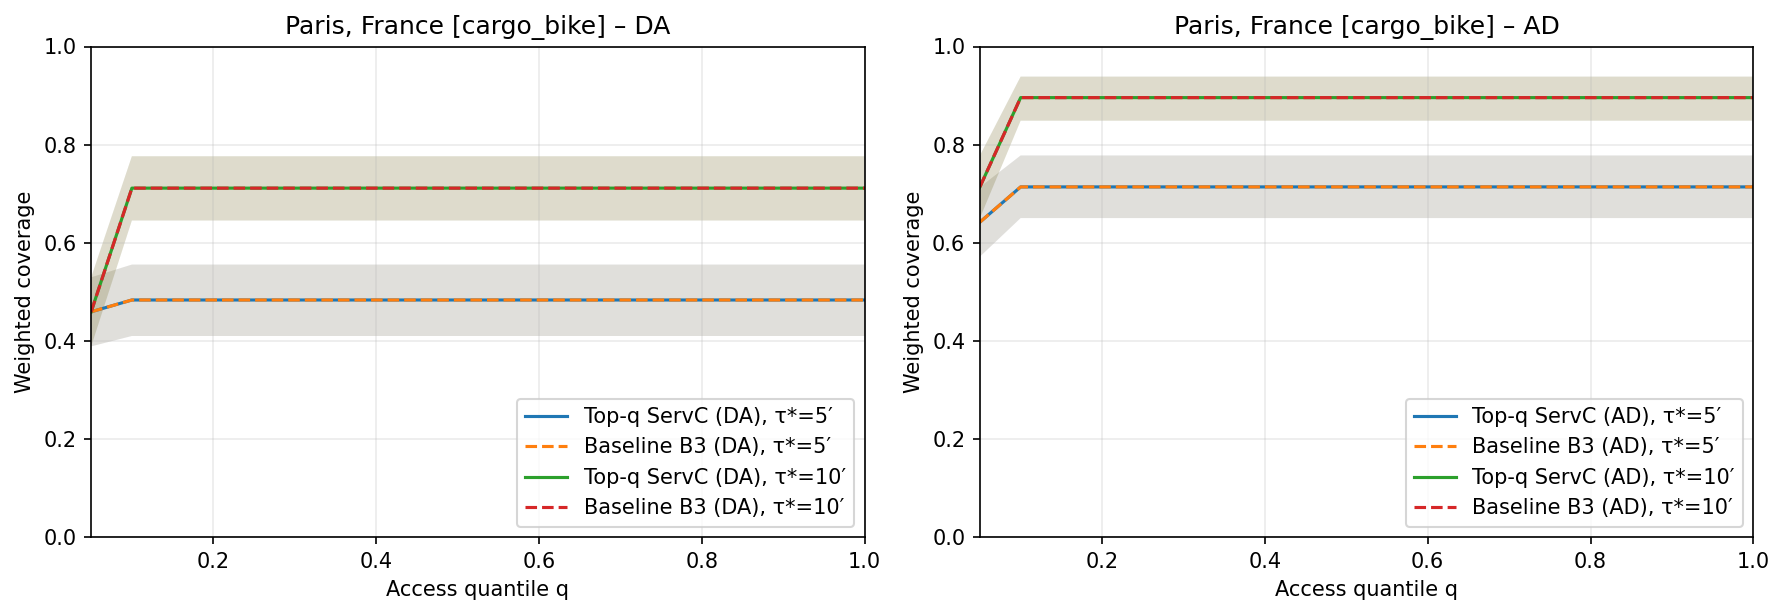

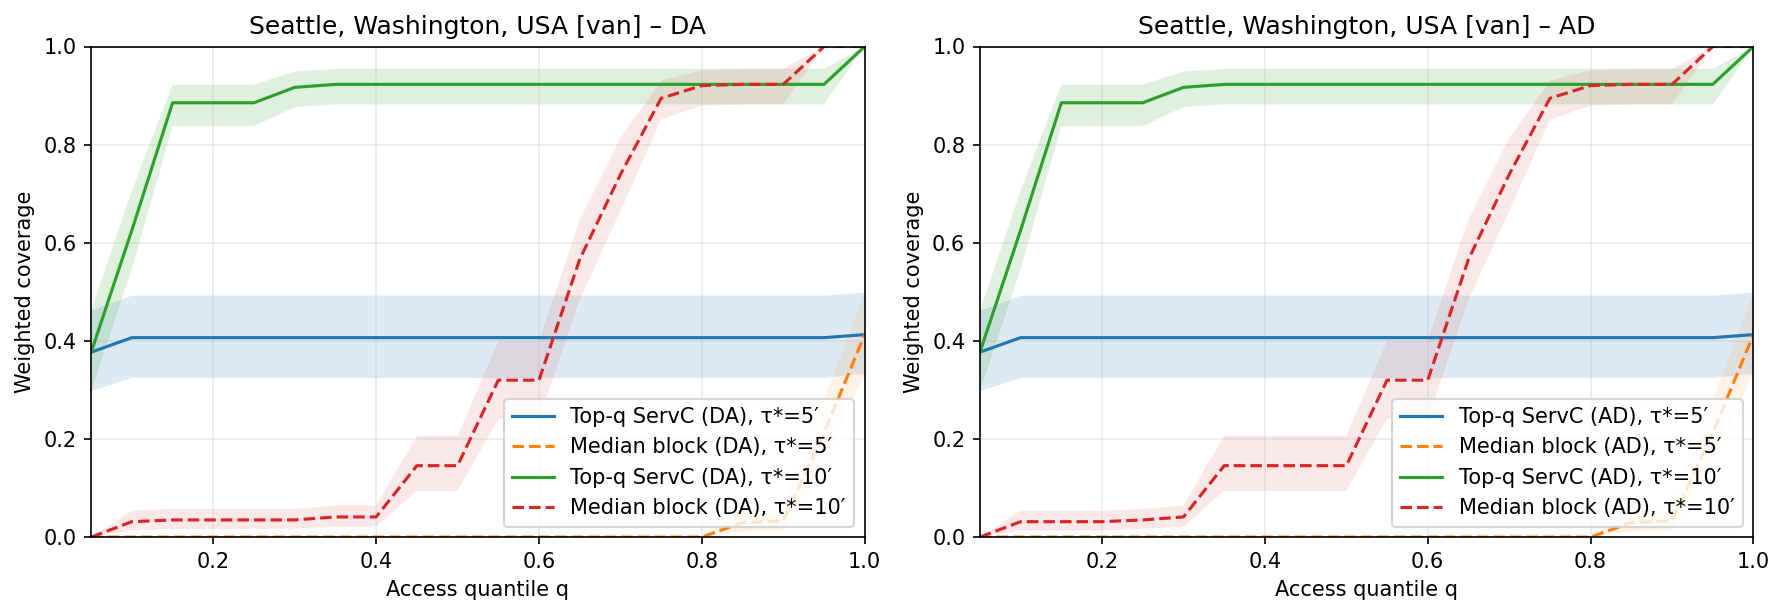

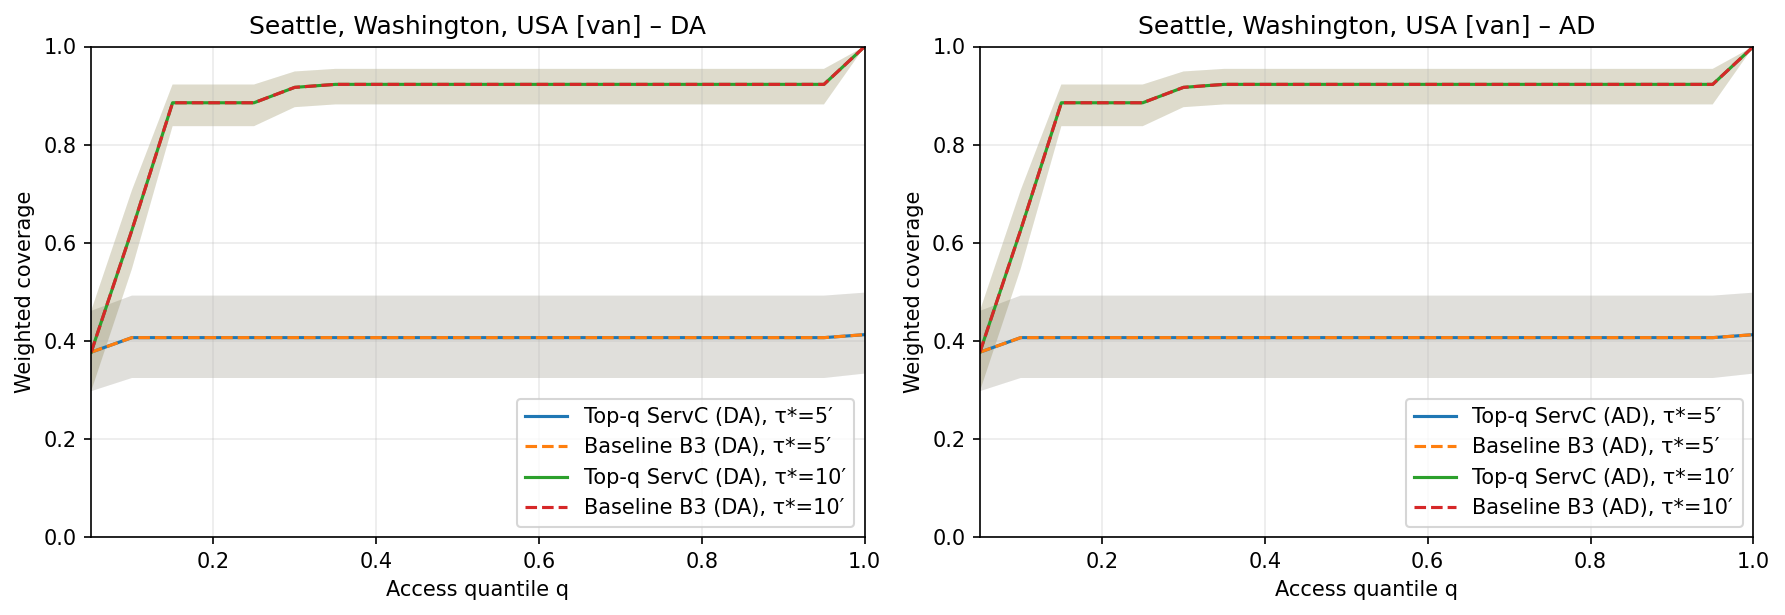

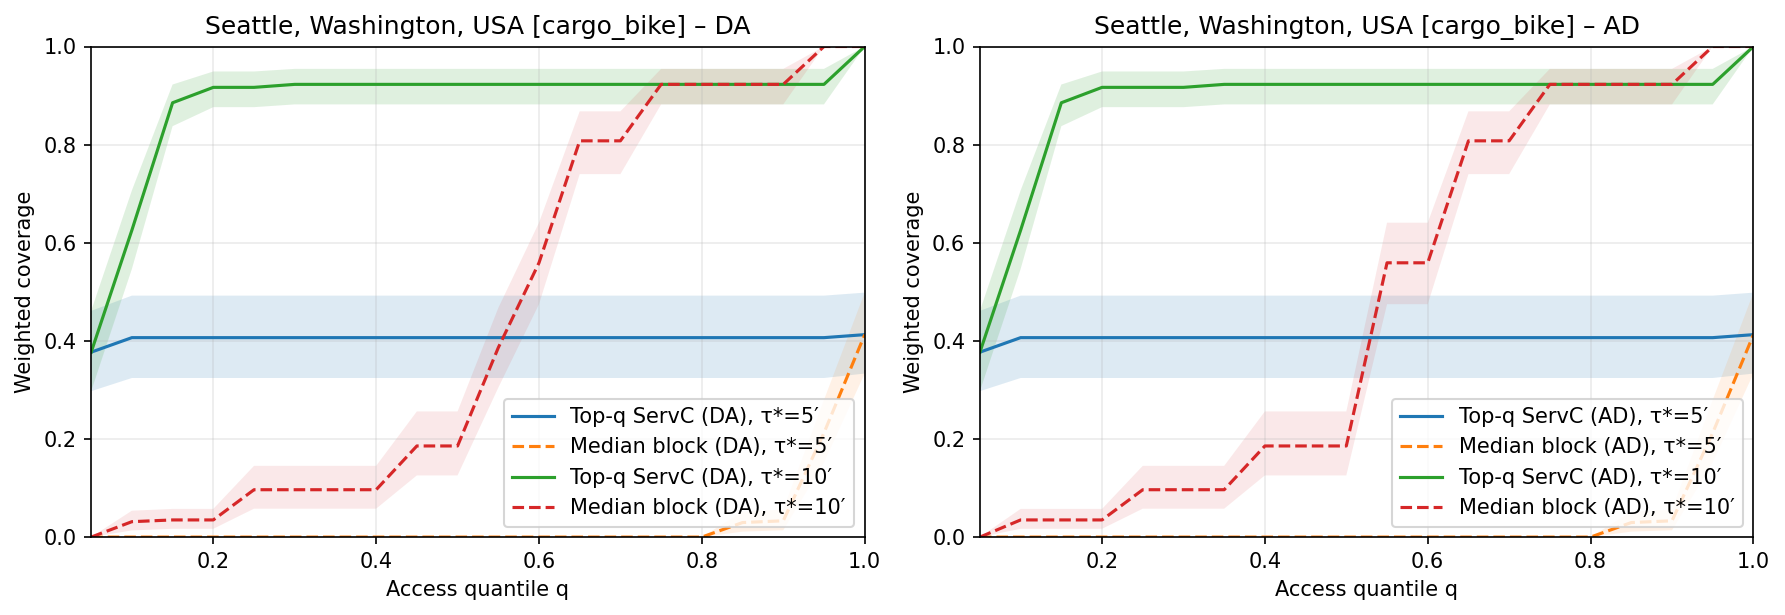

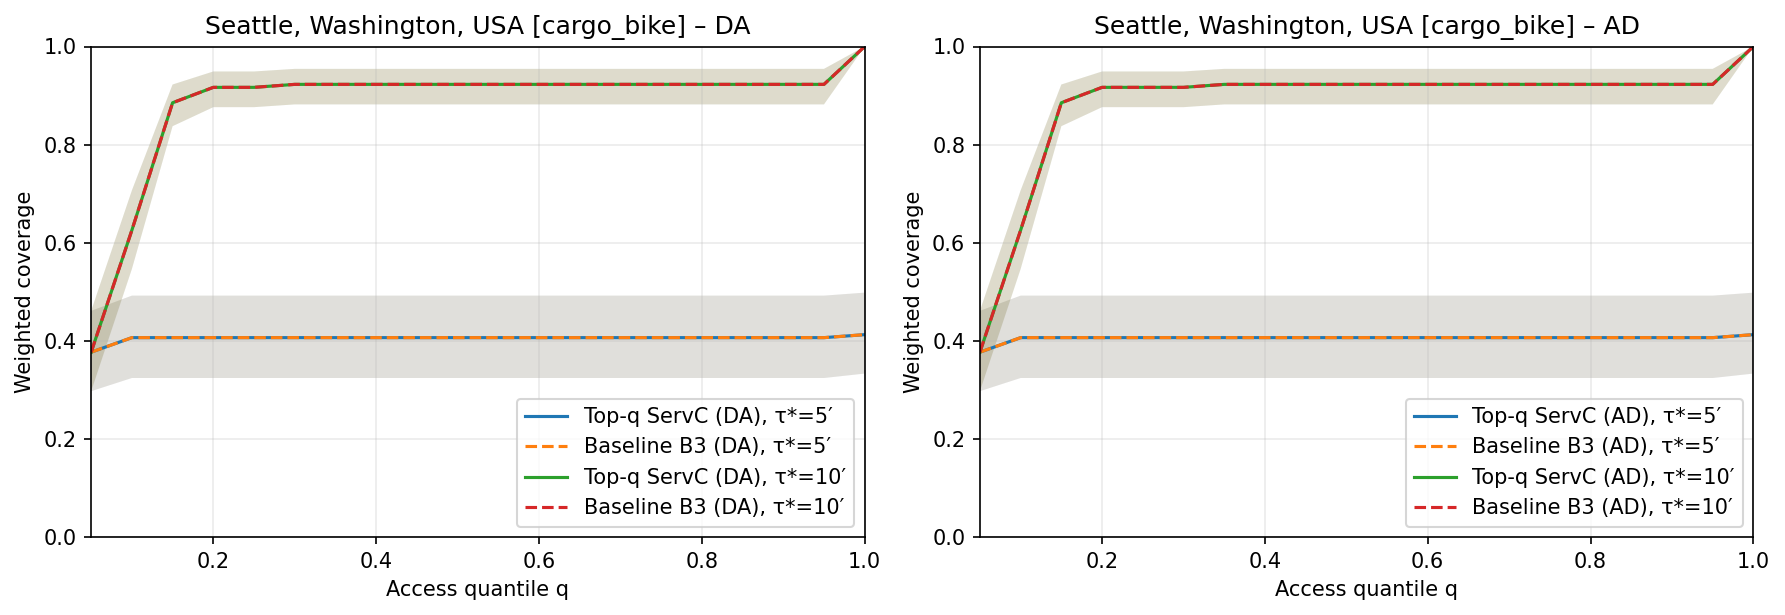

In [9]:
# h2_run_all_cities.py
# Loop H2 su tutte le città salvate in pickle (ulmm_pickles/ulmm_*.pkl)

import os
import pickle
from pathlib import Path
from typing import List, Tuple, Dict

import numpy as np
import pandas as pd
import networkx as nx

ULMM_DIR = Path("ulmm_pickles")
OUT_DIR  = Path("outputs_h2")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------
# Helpers
# ---------------------------

def slugify(name: str) -> str:
    import re
    return re.sub(r"[^a-z0-9]+", "-", name.lower()).strip("-")

def list_ulmm_pickles(directory: Path) -> List[Path]:
    return sorted(directory.glob("ulmm_*.pkl"))

def access_prox_friction(G: nx.MultiDiGraph, access_nodes: List[int], veh_key: str) -> np.ndarray:
    """
    \bar{phi}_{prox}(a) = media di phi_<veh> sugli archi incidenti al nodo d'ancoraggio di a.
    Se mancano archi/attributi, ritorna 0 per sicurezza.
    """
    phi_name = f"phi_{veh_key}"
    vals = np.zeros(len(access_nodes), dtype=float)
    for i, n in enumerate(access_nodes):
        phis = []
        # out-edges
        for _, _, _, d in G.out_edges(n, keys=True, data=True):
            if phi_name in d:
                phis.append(float(d[phi_name]))
        # in-edges
        for _, _, _, d in G.in_edges(n, keys=True, data=True):
            if phi_name in d:
                phis.append(float(d[phi_name]))
        vals[i] = float(np.mean(phis)) if len(phis) else 0.0
    return vals

def shortest_time_matrix_ad_da(
    G: nx.MultiDiGraph,
    access_nodes: List[int],
    demand_nodes: List[int],
    weight_attr: str,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Ritorna:
      tau_ad: (|A|, |D|) con tempi a->d
      tau_da: (|A|, |D|) con tempi d->a (indicizzati sempre [a,d])
    """
    A = len(access_nodes)
    D = len(demand_nodes)
    tau_ad = np.full((A, D), np.inf, dtype=float)
    tau_da = np.full((A, D), np.inf, dtype=float)

    # AD: per ogni access come sorgente, calcola distanze verso tutti i nodi
    for i, a_node in enumerate(access_nodes):
        lengths = nx.single_source_dijkstra_path_length(G, a_node, weight=weight_attr)
        for j, d_node in enumerate(demand_nodes):
            if d_node in lengths:
                tau_ad[i, j] = float(lengths[d_node])

    # DA: per ogni demand come sorgente, calcola distanze verso tutti i nodi
    for j, d_node in enumerate(demand_nodes):
        lengths = nx.single_source_dijkstra_path_length(G, d_node, weight=weight_attr)
        for i, a_node in enumerate(access_nodes):
            if a_node in lengths:
                tau_da[i, j] = float(lengths[a_node])

    return tau_ad, tau_da

# ---------------------------
# Main loop
# ---------------------------

def run_h2_all(
    ulmm_dir: Path = ULMM_DIR,
    out_dir: Path = OUT_DIR,
    vehicles: List[str] = None,
    Qgrid: np.ndarray = np.linspace(0.05, 1.0, 20),
    tau_list: Tuple[int, int] = (300, 600),  # 5 e 10 minuti
    B: int = 1000,
    kappa_for_top_vs_median: float = 0.0,   # coerente con definizione "pura" di ServC
    also_compare_servc_vs_b3: bool = True,  # opzionale: mostra effetto di kappa>0
    kappa_for_vs_b3: float = 1.0,
):
    pickles = list_ulmm_pickles(ulmm_dir)
    if not pickles:
        print(f"Nessun pickle trovato in: {ulmm_dir}")
        return

    all_rows = []

    for pkl_path in pickles:
        with open(pkl_path, "rb") as f:
            ulmm = pickle.load(f)

        city = ulmm.get("city", slugify(pkl_path.stem))
        city_slug = slugify(city)
        G: nx.MultiDiGraph = ulmm["graph"]
        dfD: pd.DataFrame = ulmm["demand"]
        dfA: pd.DataFrame = ulmm["access"]
        params: Dict = ulmm.get("params", {})

        if dfA.empty or dfD.empty:
            print(f"[SKIP] {city}: access={len(dfA)} demand={len(dfD)}")
            continue

        # Lista veicoli: prendi da pickle (se presente) o usa default
        if vehicles is None:
            veh_list = list(params.get("vehicles", {"van": {}, "cargo_bike": {}}).keys())
        else:
            veh_list = vehicles

        A_nodes = dfA["i_node"].astype(int).tolist()
        D_nodes = dfD["i_node"].astype(int).tolist()
        w_d = dfD["w"].astype(float).to_numpy()

        print(f"\n=== {city} ===  |A|={len(A_nodes)}  |D|={len(D_nodes)}")

        for veh in veh_list:
            weight_attr = f"c_eff_{veh}"
            if not any(weight_attr in d for _,_,_,d in G.edges(keys=True, data=True)):
                print(f"  [WARN] {city} [{veh}]: attributo '{weight_attr}' mancante negli archi. Skip.")
                continue

            print(f"  -> Vehicle: {veh}  (weight={weight_attr})")
            phi_prox = access_prox_friction(G, A_nodes, veh_key=veh)
            tau_ad, tau_da = shortest_time_matrix_ad_da(G, A_nodes, D_nodes, weight_attr=weight_attr)

            # Costanti inter-layer (se vuoi includerle)
            mu_DI = float(params.get("mu_DI", 0.0))
            mu_AI = float(params.get("mu_AI", 0.0))
            # Aggiungi le penalità (somma costante su righe/colonne appropriate)
            # AD: a->d ha +mu_AI (uscita da A) +mu_DI (ingresso in D) → somma costante a tutta la matrice
            tau_ad_eff = tau_ad + (mu_AI + mu_DI)
            # DA: d->a ha +mu_DI +mu_AI uguale → somma costante
            tau_da_eff = tau_da + (mu_DI + mu_AI)

            # Output dir specifici
            city_dir = out_dir / city_slug / veh
            city_dir.mkdir(parents=True, exist_ok=True)

            # --- (1) H2 "Top-q vs Median-q" (coerente con il paper)
            df1, fig1, csv1, tex1 = run_city_h2(
                city_name=f"{city} [{veh}]",
                tau_ad=tau_ad_eff,
                tau_da=tau_da_eff,
                w_d=w_d,
                phi_prox=phi_prox,
                kappa=kappa_for_top_vs_median,   # tipicamente 0.0
                Qgrid=Qgrid, tau_list=tau_list, B=B,
                out_dir=city_dir,
                compare_to="median",
            )
            all_rows.append(df1)

            # --- (2) Opzionale: ServC(kappa>0) vs B3 (mostra effetto della curb usability)
            if also_compare_servc_vs_b3:
                df2, fig2, csv2, tex2 = run_city_h2(
                    city_name=f"{city} [{veh}]",
                    tau_ad=tau_ad_eff,
                    tau_da=tau_da_eff,
                    w_d=w_d,
                    phi_prox=phi_prox,
                    kappa=kappa_for_vs_b3,        # es. 1.0 o 2.0
                    Qgrid=Qgrid, tau_list=tau_list, B=B,
                    out_dir=city_dir,
                    compare_to="B3",
                )
                all_rows.append(df2)

    # Concat risultati
    if all_rows:
        full = pd.concat(all_rows, ignore_index=True)
        out_csv = out_dir / "h2_auc_ALL.csv"
        full.to_csv(out_csv, index=False)
        print(f"\nSalvato: {out_csv.resolve()}")
    else:
        print("\nNessun risultato prodotto.")

run_h2_all(
    ulmm_dir=ULMM_DIR,
    out_dir=OUT_DIR,
    vehicles=None,                     # usa quelli presenti nel pickle
    Qgrid=np.linspace(0.05, 1.0, 20),
    tau_list=(300, 600),
    B=1000,
    kappa_for_top_vs_median=0.0,       # H2 "Top vs Median" puro
    also_compare_servc_vs_b3=True,     # opzionale
    kappa_for_vs_b3=1.0,               # penalità di prossimità per mostrare vantaggio su B3
)

In [10]:
# h2_run_all_cities.py
# H2 (ServC): loop all ULMM pickles, produce per-city figures & CSVs,
# pooled/by-city LaTeX tables, and composite grid figures.

import os
import re
import pickle
from pathlib import Path
from typing import List, Tuple, Dict, Optional

import numpy as np
import pandas as pd
import networkx as nx
from scipy.stats import binomtest
import matplotlib.pyplot as plt

# ---------------------------
# Config
# ---------------------------

ULMM_DIR = Path("ulmm_pickles")
OUT_DIR  = Path("outputs_h2")
OUT_DIR.mkdir(parents=True, exist_ok=True)

RNG_SEED = 42

# ---------------------------
# Utilities
# ---------------------------

def slugify(name: str) -> str:
    return re.sub(r"[^a-z0-9]+", "-", str(name).lower()).strip("-")

def list_ulmm_pickles(directory: Path) -> List[Path]:
    return sorted(directory.glob("ulmm_*.pkl"))

def fmt_kappa(k: float) -> str:
    # 1.0 -> k1p0 ; 0.0 -> k0p0 ; 2.5 -> k2p5
    s = f"{k:.1f}"
    return "k" + s.replace(".", "p")

# ---------------------------
# Core metric pieces
# ---------------------------

def servc_scores(tau_ad: np.ndarray,
                 tau_da: np.ndarray,
                 w_d: np.ndarray,
                 phi_prox: np.ndarray,
                 kappa: float = 0.0) -> Dict[str, np.ndarray]:
    tau_ad = np.asarray(tau_ad, dtype=float)   # |A| x |D|
    tau_da = np.asarray(tau_da, dtype=float)   # |A| x |D|
    w  = np.asarray(w_d, dtype=float).reshape(1, -1)   # 1 x |D|
    pp = np.asarray(phi_prox, dtype=float).reshape(-1, 1)  # |A| x 1
    eps = 1e-12
    servc_AD = (w / (tau_ad + kappa * pp + eps)).sum(axis=1)
    servc_DA = (w / (tau_da + kappa * pp + eps)).sum(axis=1)
    return {"servc_AD": servc_AD, "servc_DA": servc_DA}

def baseline_closeness_B3(tau_matrix: np.ndarray, w_d: np.ndarray) -> np.ndarray:
    tau = np.asarray(tau_matrix, dtype=float)
    w   = np.asarray(w_d, dtype=float).reshape(1, -1)
    eps = 1e-12
    return (w / (tau + eps)).sum(axis=1)

def top_k_indices(scores: np.ndarray, q: float) -> np.ndarray:
    A = scores.shape[0]
    k = max(1, int(np.floor(q * A)))
    return np.argsort(scores)[::-1][:k]

def median_block_indices(scores: np.ndarray, q: float) -> np.ndarray:
    # pick a contiguous block of size k around the median rank
    A = scores.shape[0]
    k = max(1, int(np.floor(q * A)))
    order = np.argsort(scores)              # ascending (worst->best)
    m = A // 2
    start = max(0, m - k // 2)
    end = start + k
    if end > A:
        end = A
        start = A - k
    return order[start:end]

def weighted_coverage_share(tau_matrix: np.ndarray,
                            w_d: np.ndarray,
                            selected_A: np.ndarray,
                            tau_star: float) -> float:
    tau = np.asarray(tau_matrix, float)
    w   = np.asarray(w_d, float)
    if selected_A.size == 0:
        return 0.0
    mins = tau[selected_A, :].min(axis=0)
    covered = (mins <= float(tau_star))
    denom = w.sum()
    return 0.0 if denom <= 0 else float(w[covered].sum() / denom)

def coverage_curve(scores_main: np.ndarray,
                   tau_matrix: np.ndarray,
                   w_d: np.ndarray,
                   Qgrid: np.ndarray,
                   tau_star: float,
                   mode: str,
                   scores_base: Optional[np.ndarray] = None) -> np.ndarray:
    cov = []
    for q in Qgrid:
        if mode == "median":
            idx = median_block_indices(scores_main, float(q))
        elif mode == "B3":
            assert scores_base is not None
            idx = top_k_indices(scores_base, float(q))
        else:
            raise ValueError("mode must be 'median' or 'B3'")
        cov.append(weighted_coverage_share(tau_matrix, w_d, idx, tau_star))
    return np.array(cov)

def auc_trapz(y: np.ndarray, x: np.ndarray) -> float:
    return float(np.trapz(y, x))

def bootstrap_curves(scores_main: np.ndarray,
                     tau_matrix: np.ndarray,
                     w_d: np.ndarray,
                     Qgrid: np.ndarray,
                     tau_star: float,
                     mode: str,
                     scores_base: Optional[np.ndarray],
                     B: int,
                     rng: np.random.Generator):
    A, D = tau_matrix.shape
    Q = len(Qgrid)
    curves_main = np.zeros((B, Q))
    curves_base = np.zeros((B, Q))
    for b in range(B):
        sample_idx = rng.integers(0, D, size=D)
        w_b   = w_d[sample_idx]
        tau_b = tau_matrix[:, sample_idx]
        # Main: top-q by ServC
        top_cov = []
        base_cov = []
        for q in Qgrid:
            idx_top = top_k_indices(scores_main, float(q))
            top_cov.append(weighted_coverage_share(tau_b, w_b, idx_top, tau_star))
            if mode == "median":
                idx_base = median_block_indices(scores_main, float(q))
            else:  # B3
                idx_base = top_k_indices(scores_base, float(q))
            base_cov.append(weighted_coverage_share(tau_b, w_b, idx_base, tau_star))
        curves_main[b] = top_cov
        curves_base[b] = base_cov
    return {"main": curves_main, "base": curves_base, "diff": curves_main - curves_base}

def ci_band(curves: np.ndarray, alpha: float = 0.05):
    lower = np.percentile(curves, 100*(alpha/2), axis=0)
    upper = np.percentile(curves, 100*(1 - alpha/2), axis=0)
    mean  = curves.mean(axis=0)
    return mean, lower, upper

def dominance_pvalues(diff_curves: np.ndarray) -> np.ndarray:
    B, Q = diff_curves.shape
    pvals = np.zeros(Q)
    for j in range(Q):
        wins = int(np.sum(diff_curves[:, j] > 0))
        pvals[j] = binomtest(wins, B, p=0.5, alternative="greater").pvalue
    return pvals

# ---------------------------
# Network helpers
# ---------------------------

def access_prox_friction(G: nx.MultiDiGraph,
                         access_nodes: List[int],
                         veh_key: str) -> np.ndarray:
    phi_name = f"phi_{veh_key}"
    vals = np.zeros(len(access_nodes), dtype=float)
    for i, n in enumerate(access_nodes):
        phis = []
        for _, _, _, d in G.out_edges(n, keys=True, data=True):
            if phi_name in d: phis.append(float(d[phi_name]))
        for _, _, _, d in G.in_edges(n, keys=True, data=True):
            if phi_name in d: phis.append(float(d[phi_name]))
        vals[i] = float(np.mean(phis)) if phis else 0.0
    return vals

def shortest_time_matrix_ad_da(G: nx.MultiDiGraph,
                               access_nodes: List[int],
                               demand_nodes: List[int],
                               weight_attr: str) -> Tuple[np.ndarray, np.ndarray]:
    A = len(access_nodes)
    D = len(demand_nodes)
    tau_ad = np.full((A, D), np.inf, dtype=float)
    tau_da = np.full((A, D), np.inf, dtype=float)

    # AD
    for i, a_node in enumerate(access_nodes):
        lengths = nx.single_source_dijkstra_path_length(G, a_node, weight=weight_attr)
        for j, d_node in enumerate(demand_nodes):
            if d_node in lengths: tau_ad[i, j] = float(lengths[d_node])

    # DA
    for j, d_node in enumerate(demand_nodes):
        lengths = nx.single_source_dijkstra_path_length(G, d_node, weight=weight_attr)
        for i, a_node in enumerate(access_nodes):
            if a_node in lengths: tau_da[i, j] = float(lengths[a_node])

    return tau_ad, tau_da

# ---------------------------
# Per-city runner (produces one 2-panel figure)
# ---------------------------

def run_city_h2(city_name: str,
                tau_ad: np.ndarray,
                tau_da: np.ndarray,
                w_d: np.ndarray,
                phi_prox: np.ndarray,
                kappa: float,
                Qgrid: np.ndarray,
                tau_list: Tuple[int, ...],
                B: int,
                out_dir: Path,
                compare_to: str,           # "median" or "B3"
                save_tag: str,             # part of filename, e.g. "median_k0p0"
                force: bool = False):
    """
    Returns (df, fig_pdf, csv, tex)
    """
    out_dir.mkdir(parents=True, exist_ok=True)
    rng = np.random.default_rng(RNG_SEED)

    # Precompute oriented ServC
    sc = servc_scores(tau_ad=tau_ad, tau_da=tau_da, w_d=w_d, phi_prox=phi_prox, kappa=kappa)
    servc_AD = sc["servc_AD"]
    servc_DA = sc["servc_DA"]

    if compare_to == "B3":
        base_AD = baseline_closeness_B3(tau_ad, w_d)
        base_DA = baseline_closeness_B3(tau_da, w_d)
        base_label = "Baseline B3"
        base_col_name = "AUC_BASE"
    elif compare_to == "median":
        base_AD = None
        base_DA = None
        base_label = "Median block"
        base_col_name = "AUC_BASE"
    else:
        raise ValueError("compare_to must be 'median' or 'B3'")

    rows = []
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), dpi=150)

    for ax, orient, scores_main, scores_base, tau_matrix in [
        (axes[0], "DA", servc_DA, base_DA, tau_da),
        (axes[1], "AD", servc_AD, base_AD, tau_ad),
    ]:
        for tau_star in tau_list:
            boot = bootstrap_curves(
                scores_main=scores_main,
                tau_matrix=tau_matrix,
                w_d=w_d,
                Qgrid=Qgrid,
                tau_star=float(tau_star),
                mode=compare_to,
                scores_base=scores_base,
                B=B,
                rng=rng
            )
            mean_m, lo_m, hi_m = ci_band(boot["main"])
            mean_b, lo_b, hi_b = ci_band(boot["base"])

            # Plot
            label_m = f"Top-q ServC ({orient}), $\\tau^*={int(tau_star/60)}'$"
            label_b = f"{base_label} ({orient}), $\\tau^*={int(tau_star/60)}'$"
            ax.plot(Qgrid, mean_m, label=label_m)
            ax.fill_between(Qgrid, lo_m, hi_m, alpha=0.15)
            ax.plot(Qgrid, mean_b, linestyle="--", label=label_b)
            ax.fill_between(Qgrid, lo_b, hi_b, alpha=0.10)

            # AUC over q (use mean curves over bootstrap)
            auc_servc = auc_trapz(mean_m, Qgrid)
            auc_base  = auc_trapz(mean_b, Qgrid)
            delta_auc = auc_servc - auc_base
            pvals = dominance_pvalues(boot["diff"])

            rows.append({
                "City": city_name,
                "Orientation": orient,
                "tau_star_sec": int(tau_star),
                "AUC_ServC": auc_servc,
                base_col_name: auc_base,
                "Delta_AUC": delta_auc,
                "Max_pval_over_q": float(np.max(pvals)),
                "Frac_q_dominate_at_5pct": float(np.mean(pvals < 0.05)),
                "Baseline": compare_to
            })

        ax.set_xlabel("Access quantile q")
        ax.set_ylabel("Weighted coverage (share of demand)")
        ax.set_title(f"{city_name} – {orient}")
        ax.set_xlim(Qgrid.min(), Qgrid.max())
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.25)
        ax.legend(loc="lower right")

    fig.tight_layout()

    city_slug = slugify(city_name)
    fig_pdf = out_dir / f"fig-servc-coverage_{save_tag}_{city_slug}.pdf"
    fig_png = out_dir / f"fig-servc-coverage_{save_tag}_{city_slug}.png"
    csv_path = out_dir / f"h2_auc_{save_tag}_{city_slug}.csv"
    tex_path = out_dir / f"h2_auc_{save_tag}_{city_slug}.tex"

    df = pd.DataFrame(rows)

    # Save
    fig.savefig(fig_pdf, bbox_inches="tight")
    fig.savefig(fig_png, bbox_inches="tight")  # PNG used later for grid collage
    df.to_csv(csv_path, index=False)

    # simple LaTeX snippet for this city
    def _fmt(x):
        return f"{x:.3f}" if isinstance(x, (float, np.floating)) else str(x)

    lines = [
        "\\begin{tabular}{lrrrrr}",
        "\\toprule",
        "Orientation & $\\tau^*$ (s) & AUC (ServC) & AUC (base) & $\\Delta$AUC & Dominance $p_{\\max}$ \\\\",
        "\\midrule",
    ]
    for _, r in df.iterrows():
        lines.append(
            f"{r['Orientation']} & {int(r['tau_star_sec'])} & {_fmt(r['AUC_ServC'])} & "
            f"{_fmt(r.get('AUC_BASE', r.get('AUC_B3', np.nan)))} & {_fmt(r['Delta_AUC'])} & "
            f"{_fmt(r['Max_pval_over_q'])} \\\\"
        )
    lines += ["\\bottomrule", "\\end{tabular}"]
    with open(tex_path, "w") as f:
        f.write("\n".join(lines))

    print(f"Saved: {fig_pdf}")
    print(f"Saved: {fig_png}")
    print(f"Saved: {csv_path}")
    print(f"Saved: {tex_path}")

    plt.close(fig)
    return df, fig_pdf, csv_path, tex_path, fig_png

# ---------------------------
# Collage (grid) of per-city figures
# ---------------------------

def make_collage_grid(image_paths: List[Path],
                      titles: List[str],
                      out_path: Path,
                      ncols: int = 2,
                      figsize_per_panel: Tuple[float,float] = (8.0, 3.0)):
    if not image_paths:
        return
    n = len(image_paths)
    nrows = int(np.ceil(n / ncols))
    fig_w = figsize_per_panel[0] * ncols
    fig_h = figsize_per_panel[1] * nrows
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), dpi=150)
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.array([axes])
    elif ncols == 1:
        axes = np.array([[ax] for ax in axes])

    for idx, (p, t) in enumerate(zip(image_paths, titles)):
        r = idx // ncols
        c = idx % ncols
        ax = axes[r, c]
        try:
            img = plt.imread(str(p))
            ax.imshow(img)
        except Exception:
            ax.text(0.5, 0.5, f"Missing image:\n{p.name}", ha="center", va="center")
        ax.set_axis_off()
        ax.set_title(t, pad=4.0, fontsize=10)

    # blank unused axes
    for idx in range(len(image_paths), nrows * ncols):
        r = idx // ncols
        c = idx % ncols
        axes[r, c].set_axis_off()

    fig.tight_layout()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {out_path}")

# ---------------------------
# Aggregation to LaTeX tables
# ---------------------------

def write_pooled_table(all_df: pd.DataFrame, out_path: Path):
    df = all_df.copy()
    # normalize baseline column name
    if "AUC_BASE" not in df.columns and "AUC_B3" in df.columns:
        df = df.rename(columns={"AUC_B3": "AUC_BASE"})
    # split City -> city + vehicle if formatted as "City [veh]"
    def split_city_veh(s):
        m = re.match(r"^(.*)\s+\[([^\]]+)\]\s*$", str(s))
        return (m.group(1), m.group(2)) if m else (s, "")
    tmp = df["City"].apply(split_city_veh)
    df["CityName"] = tmp.apply(lambda x: x[0])
    df["Vehicle"]  = tmp.apply(lambda x: x[1])

    # Group by vehicle, orientation, baseline, tau*
    grp = df.groupby(["Vehicle","Orientation","Baseline","tau_star_sec"], dropna=False)
    ag = grp.agg(
        AUC_ServC=("AUC_ServC","mean"),
        AUC_BASE=("AUC_BASE","mean"),
        Delta_AUC=("Delta_AUC","mean"),
        Max_p_over_q=("Max_pval_over_q","max"),
        Share_q_p_lt_5=("Frac_q_dominate_at_5pct","mean")
    ).reset_index()

    def _fmt(x):
        return f"{x:.3f}" if isinstance(x, (float,np.floating)) else str(x)

    lines = [
        "\\begin{table}[t]",
        "\\centering",
        "\\caption{H2 pooled results across cities. AUC over $q\\in(0,1]$ for "
        "\\(\\mathrm{ServC}^{\\xi}\\) and baselines at $\\tau^*\\in\\{5,10\\}$ minutes. "
        "$\\Delta$AUC is ServC minus baseline. Max $p$ is the worst (largest) paired "
        "one-sided dominance $p$-value across $q$; the last column is the share of "
        "$q$ with $p<0.05$.}",
        "\\label{tab:h2-pooled}",
        "\\small",
        "\\begin{tabular}{llllrrrrr}",
        "\\toprule",
        "Vehicle & Orientation & Baseline & $\\tau^*$ (s) & AUC (ServC) & AUC (base) & "
        "$\\Delta$AUC & Max $p$ & Share $q$ $p\\!<\\!.05$ \\\\",
        "\\midrule",
    ]
    for _, r in ag.sort_values(["Vehicle","Orientation","Baseline","tau_star_sec"]).iterrows():
        lines.append(
            f"{r['Vehicle']} & {r['Orientation']} & {r['Baseline']} & "
            f"{int(r['tau_star_sec'])} & {_fmt(r['AUC_ServC'])} & {_fmt(r['AUC_BASE'])} & "
            f"{_fmt(r['Delta_AUC'])} & {_fmt(r['Max_p_over_q'])} & {_fmt(r['Share_q_p_lt_5'])} \\\\"
        )
    lines += ["\\bottomrule", "\\end{tabular}", "\\end{table}"]

    with open(out_path, "w") as f:
        f.write("\n".join(lines))
    print(f"Saved: {out_path}")

def write_by_city_table(all_df: pd.DataFrame, out_path: Path):
    df = all_df.copy()
    if "AUC_BASE" not in df.columns and "AUC_B3" in df.columns:
        df = df.rename(columns={"AUC_B3": "AUC_BASE"})
    def _fmt(x):
        return f"{x:.3f}" if isinstance(x, (float,np.floating)) else str(x)

    lines = [
        "\\begin{table}[t]",
        "\\centering",
        "\\caption{H2 by city, orientation, vehicle, and threshold.}",
        "\\label{tab:h2-by-city}",
        "\\small",
        "\\begin{tabular}{l l l l r r r r r}",
        "\\toprule",
        "City & Vehicle & Orientation & Baseline & $\\tau^*$ (s) & AUC (ServC) & "
        "AUC (base) & $\\Delta$AUC & Max $p$ \\\\",
        "\\midrule",
    ]
    # split City -> name + vehicle (if present)
    def split_city_veh(s):
        m = re.match(r"^(.*)\s+\[([^\]]+)\]\s*$", str(s))
        return (m.group(1), m.group(2)) if m else (s, "")
    tmp = df["City"].apply(split_city_veh)
    df["CityName"] = tmp.apply(lambda x: x[0])
    df["Vehicle"]  = tmp.apply(lambda x: x[1])

    for _, r in df.sort_values(["CityName","Vehicle","Baseline","Orientation","tau_star_sec"]).iterrows():
        lines.append(
            f"{r['CityName']} & {r['Vehicle']} & {r['Orientation']} & {r['Baseline']} & "
            f"{int(r['tau_star_sec'])} & {_fmt(r['AUC_ServC'])} & {_fmt(r['AUC_BASE'])} & "
            f"{_fmt(r['Delta_AUC'])} & {_fmt(r['Max_pval_over_q'])} \\\\"
        )
    lines += ["\\bottomrule", "\\end{tabular}", "\\end{table}"]

    with open(out_path, "w") as f:
        f.write("\n".join(lines))
    print(f"Saved: {out_path}")

# ---------------------------
# Main loop
# ---------------------------

def run_h2_all(ulmm_dir: Path = ULMM_DIR,
               out_dir: Path = OUT_DIR,
               vehicles: Optional[List[str]] = None,
               Qgrid: np.ndarray = np.linspace(0.05, 1.0, 20),
               tau_list: Tuple[int, ...] = (300, 600),
               B: int = 1000,
               kappa_for_top_vs_median: float = 0.0,
               also_compare_servc_vs_b3: bool = True,
               kappa_for_vs_b3: float = 1.0,
               force: bool = False):

    pickles = list_ulmm_pickles(ulmm_dir)
    if not pickles:
        print(f"No pickles in: {ulmm_dir}")
        return

    all_rows = []
    collage_median_paths = []
    collage_median_titles = []
    collage_b3_paths = []
    collage_b3_titles = []

    for pkl in pickles:
        with open(pkl, "rb") as f:
            ulmm = pickle.load(f)

        city = ulmm.get("city", pkl.stem.replace("ulmm_", ""))
        G: nx.MultiDiGraph = ulmm["graph"]
        dfD: pd.DataFrame = ulmm["demand"]
        dfA: pd.DataFrame = ulmm["access"]
        params: Dict = ulmm.get("params", {})

        if dfA.empty or dfD.empty:
            print(f"[SKIP] {city}: access={len(dfA)} demand={len(dfD)}")
            continue

        if vehicles is None:
            veh_list = list(params.get("vehicles", {"van": {}, "cargo_bike": {}}).keys())
        else:
            veh_list = vehicles

        A_nodes = dfA["i_node"].astype(int).tolist()
        D_nodes = dfD["i_node"].astype(int).tolist()
        w_d     = dfD["w"].astype(float).to_numpy()

        mu_DI = float(params.get("mu_DI", 0.0))
        mu_AI = float(params.get("mu_AI", 0.0))

        print(f"\n=== {city} === |A|={len(A_nodes)} |D|={len(D_nodes)}")

        for veh in veh_list:
            weight_attr = f"c_eff_{veh}"
            # quick check for attribute existence
            has_weight = False
            for _,_,_,d in G.edges(keys=True, data=True):
                if weight_attr in d:
                    has_weight = True; break
            if not has_weight:
                print(f"  [WARN] {city} [{veh}]: missing edge attr '{weight_attr}'. Skip.")
                continue

            city_veh_name = f"{city} [{veh}]"
            city_slug = slugify(city)
            veh_dir = out_dir / city_slug / veh
            veh_dir.mkdir(parents=True, exist_ok=True)

            print(f"  -> Vehicle: {veh} (weight={weight_attr})")

            phi_prox = access_prox_friction(G, A_nodes, veh_key=veh)
            tau_ad, tau_da = shortest_time_matrix_ad_da(G, A_nodes, D_nodes, weight_attr=weight_attr)
            tau_ad_eff = tau_ad + (mu_AI + mu_DI)
            tau_da_eff = tau_da + (mu_DI + mu_AI)

            # (1) Top-q vs Median block (kappa for paper default 0.0)
            tag_median = f"median_{fmt_kappa(kappa_for_top_vs_median)}"
            df1, fig1_pdf, csv1, tex1, fig1_png = run_city_h2(
                city_name=city_veh_name,
                tau_ad=tau_ad_eff, tau_da=tau_da_eff,
                w_d=w_d, phi_prox=phi_prox,
                kappa=kappa_for_top_vs_median,
                Qgrid=Qgrid, tau_list=tau_list, B=B,
                out_dir=veh_dir,
                compare_to="median",
                save_tag=tag_median,
                force=force
            )
            all_rows.append(df1)
            collage_median_paths.append(fig1_png)
            collage_median_titles.append(f"{city} [{veh}]")

            # (2) Optional: ServC vs B3 with kappa>0 (shows curb-usability)
            if also_compare_servc_vs_b3:
                tag_b3 = f"B3_{fmt_kappa(kappa_for_vs_b3)}"
                df2, fig2_pdf, csv2, tex2, fig2_png = run_city_h2(
                    city_name=city_veh_name,
                    tau_ad=tau_ad_eff, tau_da=tau_da_eff,
                    w_d=w_d, phi_prox=phi_prox,
                    kappa=kappa_for_vs_b3,
                    Qgrid=Qgrid, tau_list=tau_list, B=B,
                    out_dir=veh_dir,
                    compare_to="B3",
                    save_tag=tag_b3,
                    force=force
                )
                all_rows.append(df2)
                collage_b3_paths.append(fig2_png)
                collage_b3_titles.append(f"{city} [{veh}]")

    # Concatenate all results and write master CSV
    if not all_rows:
        print("\nNo results generated.")
        return
    full = pd.concat(all_rows, ignore_index=True)
    # normalize baseline column name for consistency
    if "AUC_BASE" not in full.columns and "AUC_B3" in full.columns:
        full = full.rename(columns={"AUC_B3": "AUC_BASE"})
    out_csv = out_dir / "h2_auc_ALL.csv"
    full.to_csv(out_csv, index=False)
    print(f"\nSaved: {out_csv}")

    # Pooled and by-city LaTeX tables
    write_pooled_table(full, out_dir / "h2_pooled.tex")
    write_by_city_table(full, out_dir / "h2_by_city.tex")

    # Collage grids (two: median and B3, if available)
    if collage_median_paths:
        make_collage_grid(collage_median_paths, collage_median_titles,
                          out_dir / "fig-servc-coverage-grid_median.pdf",
                          ncols=2, figsize_per_panel=(8.0, 3.0))
    if collage_b3_paths:
        make_collage_grid(collage_b3_paths, collage_b3_titles,
                          out_dir / "fig-servc-coverage-grid_B3.pdf",
                          ncols=2, figsize_per_panel=(8.0, 3.0))

run_h2_all(
    ulmm_dir=ULMM_DIR,
    out_dir=OUT_DIR,
    vehicles=None,                       # use vehicles found in pickle
    Qgrid=np.linspace(0.05, 1.0, 20),
    tau_list=(300, 600),                 # 5' and 10'
    B=1000,
    kappa_for_top_vs_median=0.0,         # paper default for "Top vs Median"
    also_compare_servc_vs_b3=True,       # optional comparison
    kappa_for_vs_b3=1.0,                 # show curb usability effect
    force=False
)


=== Amsterdam, Netherlands === |A|=30 |D|=409
  -> Vehicle: van (weight=c_eff_van)
Saved: outputs_h2/amsterdam-netherlands/van/fig-servc-coverage_median_k0p0_amsterdam-netherlands-van.pdf
Saved: outputs_h2/amsterdam-netherlands/van/fig-servc-coverage_median_k0p0_amsterdam-netherlands-van.png
Saved: outputs_h2/amsterdam-netherlands/van/h2_auc_median_k0p0_amsterdam-netherlands-van.csv
Saved: outputs_h2/amsterdam-netherlands/van/h2_auc_median_k0p0_amsterdam-netherlands-van.tex
Saved: outputs_h2/amsterdam-netherlands/van/fig-servc-coverage_B3_k1p0_amsterdam-netherlands-van.pdf
Saved: outputs_h2/amsterdam-netherlands/van/fig-servc-coverage_B3_k1p0_amsterdam-netherlands-van.png
Saved: outputs_h2/amsterdam-netherlands/van/h2_auc_B3_k1p0_amsterdam-netherlands-van.csv
Saved: outputs_h2/amsterdam-netherlands/van/h2_auc_B3_k1p0_amsterdam-netherlands-van.tex
  -> Vehicle: cargo_bike (weight=c_eff_cargo_bike)
Saved: outputs_h2/amsterdam-netherlands/cargo_bike/fig-servc-coverage_median_k0p0_amsterd